# 🌡️ Climate Trend Analyzer: Advanced Weather & Rainfall Analysis

## India Weather Intelligence & Climate Risk Analytics

**Dataset:** [https://www.kaggle.com/datasets/ameydilipmorye/indian-rainfall-and-weather-data](Click here to download)  
**Records:** 150,000+ weather observations across India  
**Focus:** Exploratory analysis, seasonal patterns, anomaly detection, and geographical insights

---

### 📊 Analysis Sections:
1. **Exploratory Climate Analysis** - Overall weather patterns and correlations
2. **Seasonal Trend Analysis** - Climate behavior by season
3. **Anomaly Analysis** - Extreme weather events detection
4. **Geographical Insights** - Spatial climate variations
5. **Business Summary** - Key findings and actionable insights


In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Set visualization defaults
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("✓ All libraries imported successfully!")


✓ All libraries imported successfully!


In [2]:
# Load Dataset
file_path = 'processed_weather_rainfall_data.csv'
df = pd.read_csv(file_path)

print("="*80)
print("DATASET LOADING SUMMARY")
print("="*80)
print(f"\n✓ Dataset loaded successfully!")
print(f"  - Shape: {df.shape}")
print(f"  - Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\n✓ Data Types:")
print(df.dtypes)
print(f"\n✓ First few rows:")
print(df.head())
print(f"\n✓ Dataset Info:")
print(f"  - Unique States: {df['state'].nunique()}")
print(f"  - Unique Districts: {df['district'].nunique()}")
print(f"  - Unique Stations: {df['station_name'].nunique()}")
print(f"  - Unique Seasons: {df['season'].nunique()}")
print(f"  - Date range: {df['date_of_record'].min()} to {df['date_of_record'].max()}")


DATASET LOADING SUMMARY

✓ Dataset loaded successfully!
  - Shape: (150000, 29)
  - Memory usage: 74.43 MB

✓ Data Types:
date_of_record          object
month                   object
season                  object
station_name            object
state                   object
district                object
avg_temp               float64
min_temp               float64
max_temp               float64
wind_speed             float64
air_pressure           float64
elevation                int64
latitude               float64
longitude              float64
rainfall               float64
Year                     int64
Month                    int64
Day                      int64
DayOfYear                int64
Quarter                  int64
WeekOfYear               int64
Heavy_Rainfall           int64
Light_Rainfall           int64
Unusual_Hot_Global       int64
Unusual_Cold_Global      int64
Unusual_Hot_Local        int64
Unusual_Cold_Local       int64
Temp_Range             float64
Pressure_A

---

# Section 6: 🔍 Exploratory Climate Analysis

**Objective:** Understand overall weather and climate behavior patterns

### Analysis Components:
- Temperature distribution analysis
- Rainfall pattern distribution
- State-wise temperature comparison
- Station-wise rainfall comparison
- Correlation analysis between weather variables



6.1 TEMPERATURE DISTRIBUTION ANALYSIS

✓ Temperature Statistics (°C):
        Avg Temp   Min Temp   Max Temp
count  150000.00  150000.00  150000.00
mean       22.34      16.41      28.86
std         8.02       8.03       7.75
min       -10.40     -18.50      -5.60
25%        16.30      10.20      23.80
50%        23.10      16.60      29.70
75%        28.90      23.60      34.30
max        42.20      36.60      87.00


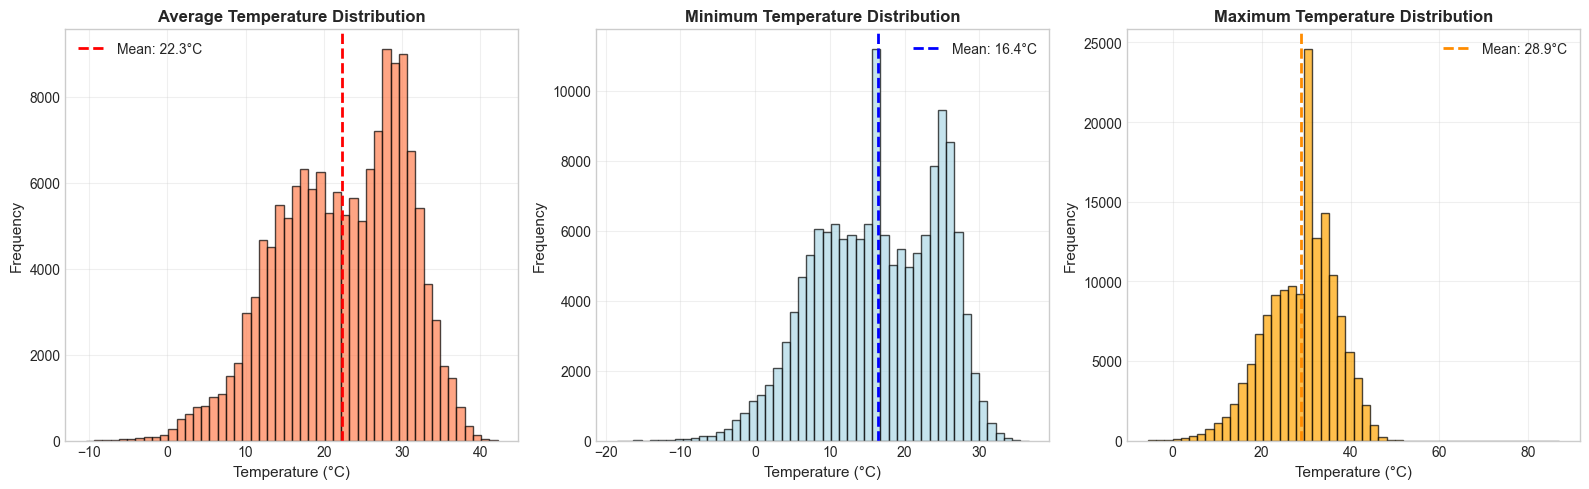

✓ Temperature distributions visualized


In [3]:
# 6.1 Temperature Distribution Analysis
print("\n" + "="*80)
print("6.1 TEMPERATURE DISTRIBUTION ANALYSIS")
print("="*80)

# Summary statistics for temperatures
temp_stats = pd.DataFrame({
    'Avg Temp': df['avg_temp'].describe(),
    'Min Temp': df['min_temp'].describe(),
    'Max Temp': df['max_temp'].describe()
}).round(2)

print("\n✓ Temperature Statistics (°C):")
print(temp_stats)

# Visualize temperature distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Average Temperature Distribution
axes[0].hist(df['avg_temp'].dropna(), bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[0].axvline(df['avg_temp'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {df['avg_temp'].mean():.1f}°C")
axes[0].set_xlabel('Temperature (°C)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Average Temperature Distribution', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Min Temperature Distribution
axes[1].hist(df['min_temp'].dropna(), bins=50, color='lightblue', edgecolor='black', alpha=0.7)
axes[1].axvline(df['min_temp'].mean(), color='blue', linestyle='--', linewidth=2, label=f"Mean: {df['min_temp'].mean():.1f}°C")
axes[1].set_xlabel('Temperature (°C)', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_title('Minimum Temperature Distribution', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Max Temperature Distribution
axes[2].hist(df['max_temp'].dropna(), bins=50, color='orange', edgecolor='black', alpha=0.7)
axes[2].axvline(df['max_temp'].mean(), color='darkorange', linestyle='--', linewidth=2, label=f"Mean: {df['max_temp'].mean():.1f}°C")
axes[2].set_xlabel('Temperature (°C)', fontsize=11)
axes[2].set_ylabel('Frequency', fontsize=11)
axes[2].set_title('Maximum Temperature Distribution', fontsize=12, fontweight='bold')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Temperature distributions visualized")



6.2 RAINFALL DISTRIBUTION ANALYSIS

✓ Rainfall Statistics (mm):
count    150000.00
mean          3.09
std          11.02
min           0.00
25%           0.00
50%           0.00
75%           0.50
max         460.50
Name: rainfall, dtype: float64

✓ Rainfall Additional Insights:
  - Days with no rainfall: 104949 (70.0%)
  - Days with rainfall > 50mm: 1675 (1.1%)
  - Days with heavy rainfall (>100mm): 294 (0.2%)


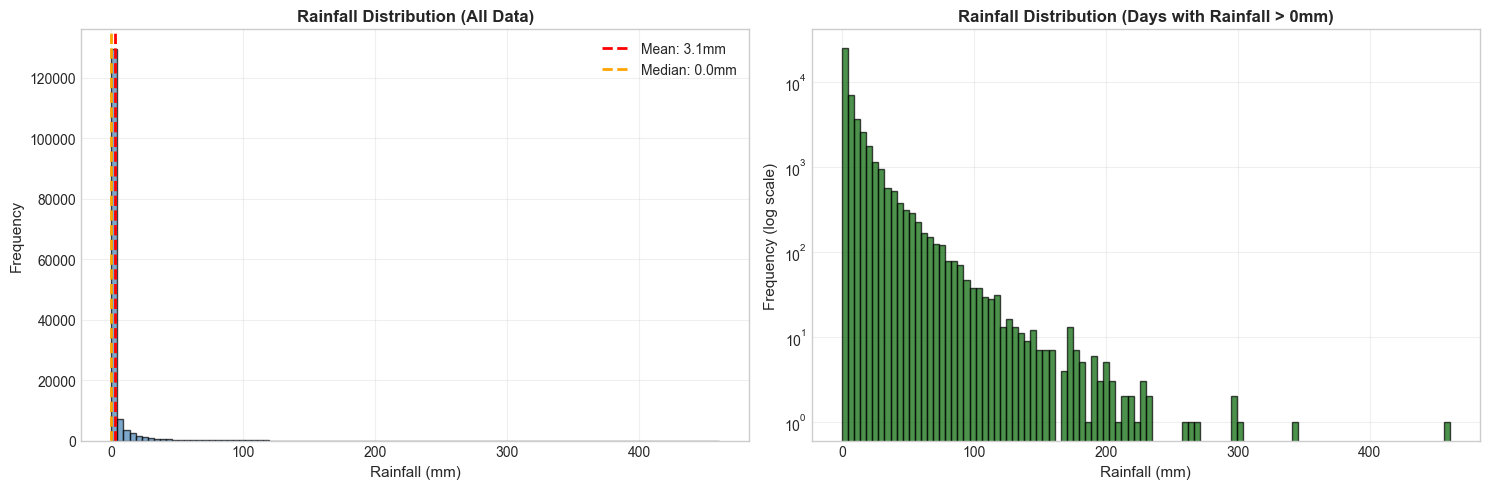

✓ Rainfall distributions visualized


In [4]:
# 6.2 Rainfall Distribution Analysis
print("\n" + "="*80)
print("6.2 RAINFALL DISTRIBUTION ANALYSIS")
print("="*80)

# Summary statistics for rainfall
rainfall_stats = df['rainfall'].describe().round(2)
print("\n✓ Rainfall Statistics (mm):")
print(rainfall_stats)

# Additional rainfall insights
print(f"\n✓ Rainfall Additional Insights:")
print(f"  - Days with no rainfall: {(df['rainfall'] == 0).sum()} ({(df['rainfall'] == 0).sum()/len(df)*100:.1f}%)")
print(f"  - Days with rainfall > 50mm: {(df['rainfall'] > 50).sum()} ({(df['rainfall'] > 50).sum()/len(df)*100:.1f}%)")
print(f"  - Days with heavy rainfall (>100mm): {(df['rainfall'] > 100).sum()} ({(df['rainfall'] > 100).sum()/len(df)*100:.1f}%)")

# Visualize rainfall distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Rainfall histogram (all data)
axes[0].hist(df['rainfall'].dropna(), bins=100, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(df['rainfall'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {df['rainfall'].mean():.1f}mm")
axes[0].axvline(df['rainfall'].median(), color='orange', linestyle='--', linewidth=2, label=f"Median: {df['rainfall'].median():.1f}mm")
axes[0].set_xlabel('Rainfall (mm)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Rainfall Distribution (All Data)', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Rainfall log scale (better view of distribution)
rainfall_non_zero = df[df['rainfall'] > 0]['rainfall']
axes[1].hist(rainfall_non_zero, bins=100, color='darkgreen', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Rainfall (mm)', fontsize=11)
axes[1].set_ylabel('Frequency (log scale)', fontsize=11)
axes[1].set_yscale('log')
axes[1].set_title('Rainfall Distribution (Days with Rainfall > 0mm)', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Rainfall distributions visualized")



6.3 STATE-WISE TEMPERATURE COMPARISON

✓ State-wise Temperature Statistics:
       Avg_Temp_Mean  Avg_Temp_Min  Avg_Temp_Max  Avg_Temp_Std  Avg_Rainfall
state                                                                       
RJ             25.87           4.9          41.3          7.12          1.19
MP             25.66           5.1          40.7          7.19          1.66
DL             25.30           6.4          40.4          7.40          2.06
AS             24.72          12.9          36.7          4.51          7.71
AR             24.01          13.4          33.6          4.28         11.20
HR             23.60           4.3          40.3          7.62          1.85
CH             23.50           6.1          38.6          7.14          2.49
PB             23.39           5.0          42.2          7.71          2.08
UP             22.49          -0.7          39.9          7.33          3.08
HP             18.51          -1.1          37.6          6.98          3.94

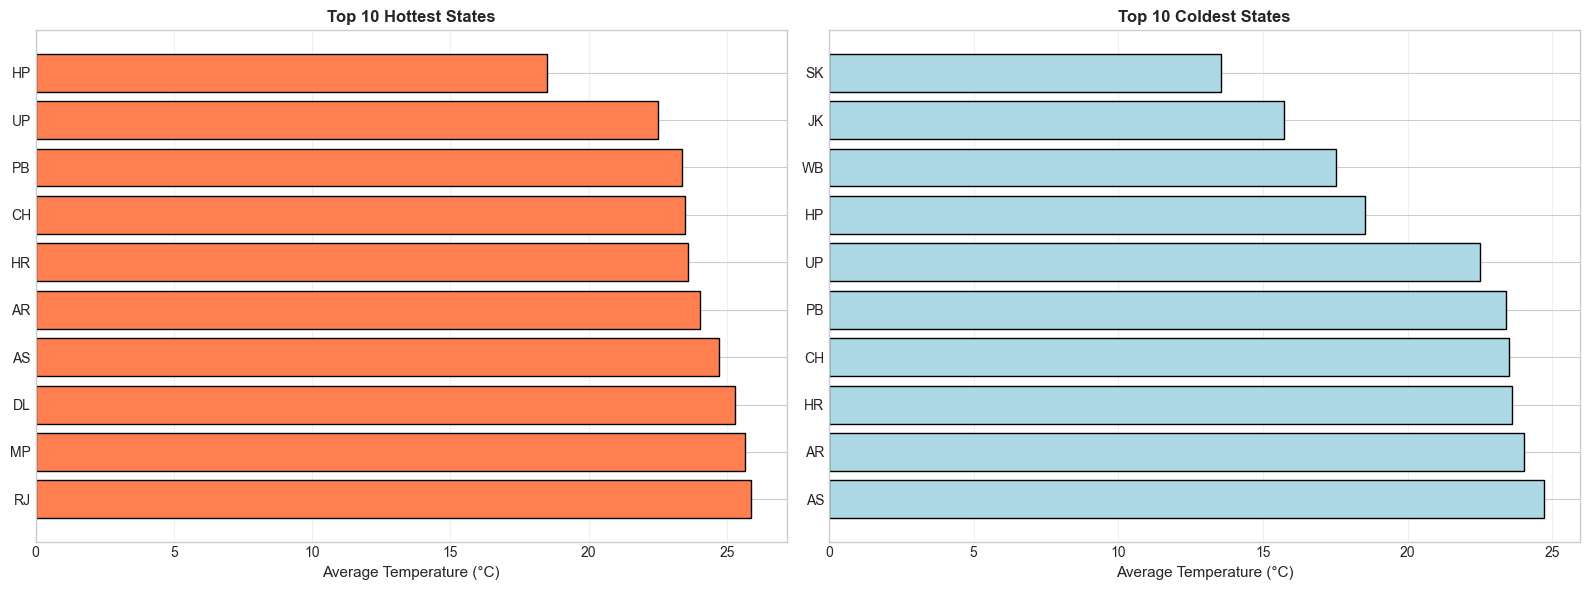

✓ State-wise temperature comparison visualized


In [5]:
# 6.3 State-wise Temperature Comparison
print("\n" + "="*80)
print("6.3 STATE-WISE TEMPERATURE COMPARISON")
print("="*80)

# Calculate state-wise temperature statistics
state_temp = df.groupby('state').agg({
    'avg_temp': ['mean', 'min', 'max', 'std'],
    'rainfall': 'mean'
}).round(2)

state_temp.columns = ['Avg_Temp_Mean', 'Avg_Temp_Min', 'Avg_Temp_Max', 'Avg_Temp_Std', 'Avg_Rainfall']
state_temp = state_temp.sort_values('Avg_Temp_Mean', ascending=False)

print("\n✓ State-wise Temperature Statistics:")
print(state_temp.head(10))

# Top 10 hottest states
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Hottest states
state_temp_top = state_temp.head(10)
axes[0].barh(state_temp_top.index, state_temp_top['Avg_Temp_Mean'], color='coral', edgecolor='black')
axes[0].set_xlabel('Average Temperature (°C)', fontsize=11)
axes[0].set_title('Top 10 Hottest States', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3, axis='x')

# Coldest states
state_temp_bottom = state_temp.tail(10)
axes[1].barh(state_temp_bottom.index, state_temp_bottom['Avg_Temp_Mean'], color='lightblue', edgecolor='black')
axes[1].set_xlabel('Average Temperature (°C)', fontsize=11)
axes[1].set_title('Top 10 Coldest States', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("✓ State-wise temperature comparison visualized")



6.4 STATION-WISE RAINFALL COMPARISON

✓ Top 10 Wettest Stations:
                       Avg_Rainfall_Mean  Total_Rainfall  Max_Rainfall  \
station_name                                                             
Pasighat                           11.20         34835.6         296.9   
Gangtok                            11.15         16600.6         146.5   
North Lakhimpur                     8.91         32878.0         188.0   
Kalimpong                           7.90         10297.1         233.1   
Manali                              6.78          8837.5         114.0   
Dibrugarh / Mohanbari               6.51         24032.1         195.1   
Darjeeling                          6.31         11805.0         233.9   
Dharmsala                           5.63          8379.0         176.2   
Dehradun                            5.12         18891.1         177.0   
Nainital                            4.75          7071.4         230.1   

                       Avg_Temp State  
stati

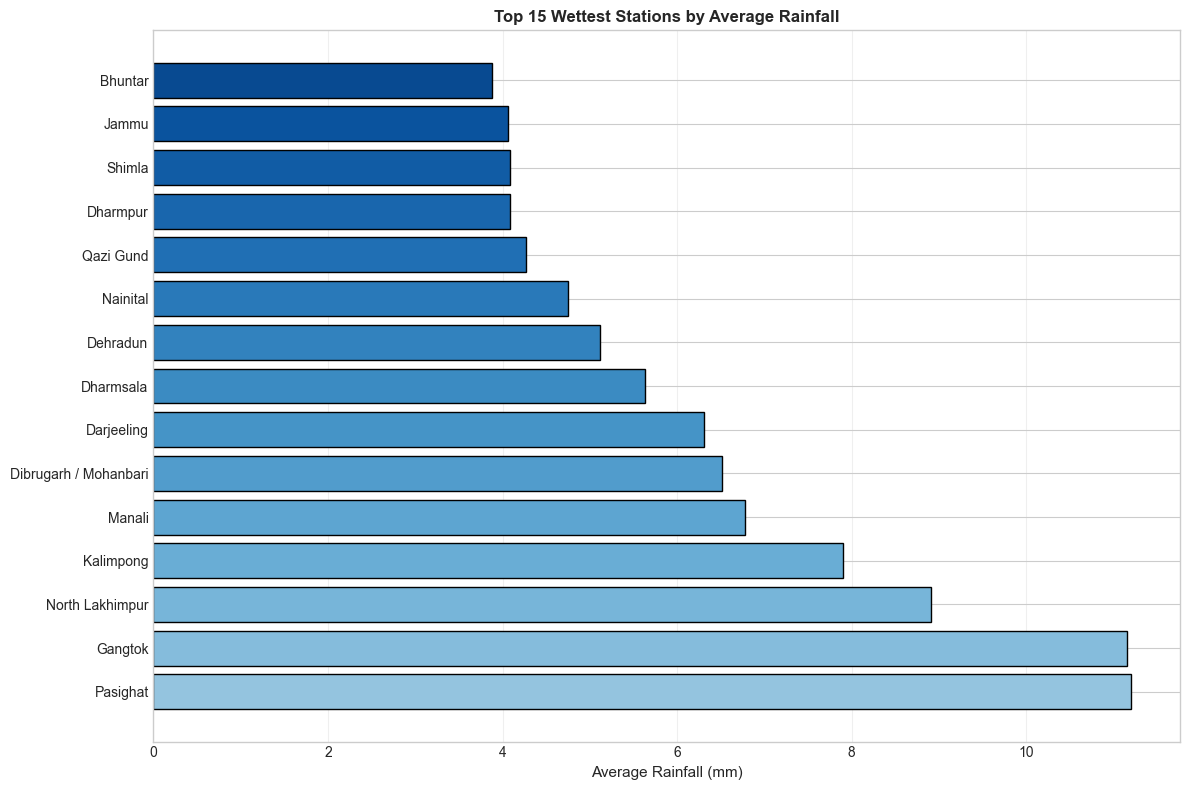

✓ Station-wise rainfall comparison visualized


In [6]:
# 6.4 Station-wise Rainfall Comparison
print("\n" + "="*80)
print("6.4 STATION-WISE RAINFALL COMPARISON")
print("="*80)

# Calculate station-wise rainfall statistics
station_rainfall = df.groupby('station_name').agg({
    'rainfall': ['mean', 'sum', 'max'],
    'avg_temp': 'mean',
    'state': 'first'
}).round(2)

station_rainfall.columns = ['Avg_Rainfall_Mean', 'Total_Rainfall', 'Max_Rainfall', 'Avg_Temp', 'State']
station_rainfall = station_rainfall.sort_values('Avg_Rainfall_Mean', ascending=False)

print("\n✓ Top 10 Wettest Stations:")
print(station_rainfall.head(10))

print("\n✓ Top 10 Driest Stations:")
print(station_rainfall.tail(10))

# Visualize top 15 stations by rainfall
fig, ax = plt.subplots(figsize=(12, 8))
top_stations = station_rainfall.head(15)
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(top_stations)))
ax.barh(range(len(top_stations)), top_stations['Avg_Rainfall_Mean'], color=colors, edgecolor='black')
ax.set_yticks(range(len(top_stations)))
ax.set_yticklabels(top_stations.index)
ax.set_xlabel('Average Rainfall (mm)', fontsize=11)
ax.set_title('Top 15 Wettest Stations by Average Rainfall', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("✓ Station-wise rainfall comparison visualized")



6.5 CORRELATION ANALYSIS

✓ Correlation Matrix:
                  avg_temp  min_temp  max_temp  wind_speed  air_pressure  \
avg_temp             1.000     0.939     0.914       0.297        -0.687   
min_temp             0.939     1.000     0.824       0.318        -0.733   
max_temp             0.914     0.824     1.000       0.306        -0.646   
wind_speed           0.297     0.318     0.306       1.000        -0.351   
air_pressure        -0.687    -0.733    -0.646      -0.351         1.000   
elevation           -0.471    -0.410    -0.492      -0.202         0.196   
latitude            -0.340    -0.341    -0.297      -0.201         0.202   
longitude           -0.004     0.029    -0.092      -0.151        -0.004   
rainfall             0.022     0.094    -0.052      -0.017        -0.112   
Temp_Range          -0.097    -0.350     0.242      -0.039         0.188   
Pressure_Anomaly     0.048     0.068     0.029       0.127        -0.170   

                  elevation  latitude 

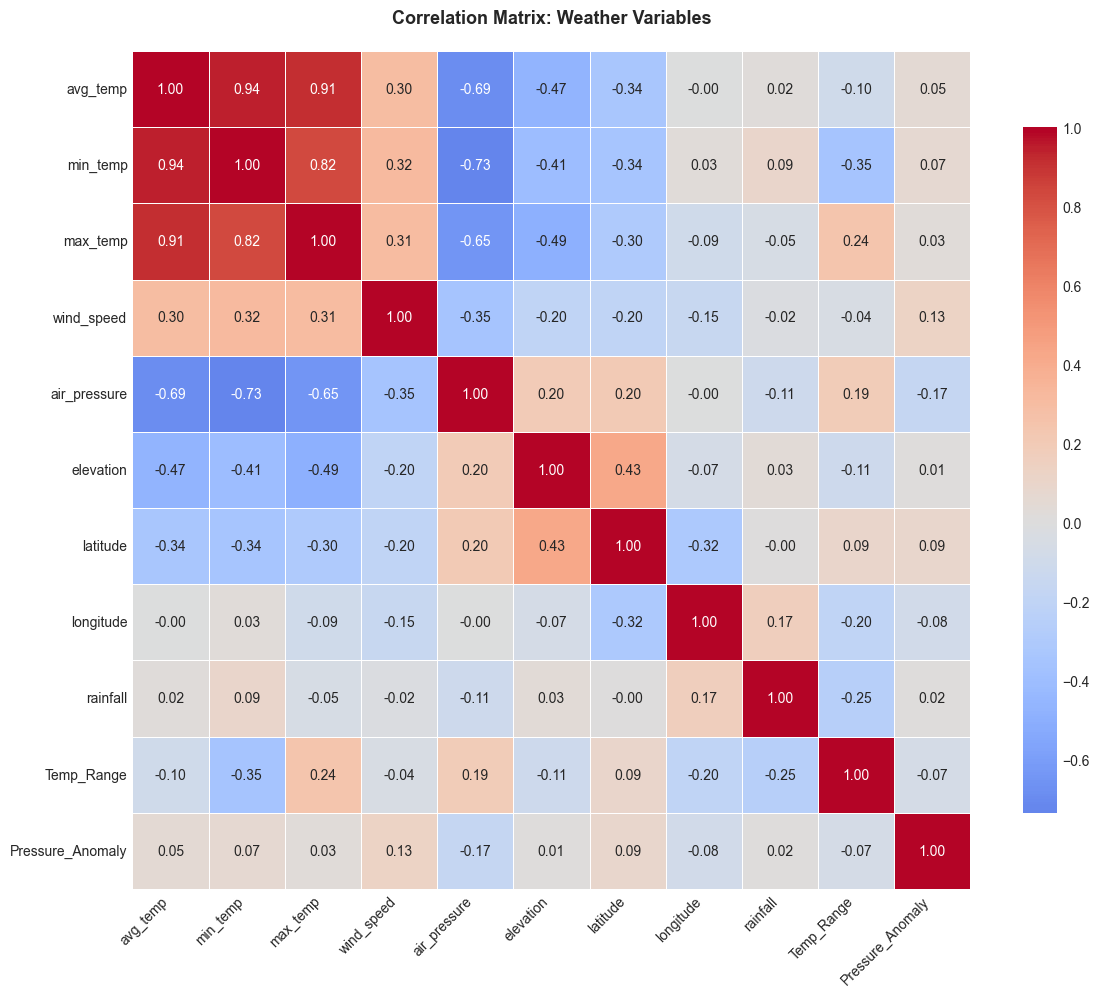


✓ Correlations with Rainfall:
rainfall            1.000000
longitude           0.171467
min_temp            0.093892
elevation           0.031794
avg_temp            0.021919
Pressure_Anomaly    0.015821
latitude           -0.000758
wind_speed         -0.017324
max_temp           -0.052378
air_pressure       -0.112116
Temp_Range         -0.247639
Name: rainfall, dtype: float64

✓ Correlations with Avg Temperature:
avg_temp            1.000000
min_temp            0.939331
max_temp            0.914092
wind_speed          0.297372
Pressure_Anomaly    0.048346
rainfall            0.021919
longitude          -0.003939
Temp_Range         -0.097183
latitude           -0.339632
elevation          -0.470645
air_pressure       -0.686589
Name: avg_temp, dtype: float64
✓ Correlation analysis completed


In [7]:
# 6.5 Correlation Analysis Heatmap
print("\n" + "="*80)
print("6.5 CORRELATION ANALYSIS")
print("="*80)

# Select numerical columns for correlation
numerical_cols = ['avg_temp', 'min_temp', 'max_temp', 'wind_speed', 'air_pressure', 
                  'elevation', 'latitude', 'longitude', 'rainfall', 'Temp_Range', 'Pressure_Anomaly']

# Calculate correlation matrix
correlation_matrix = df[numerical_cols].corr()

print("\n✓ Correlation Matrix:")
print(correlation_matrix.round(3))

# Visualize correlation heatmap
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Correlation Matrix: Weather Variables', fontsize=13, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Key correlations with Rainfall
print("\n✓ Correlations with Rainfall:")
rainfall_corr = correlation_matrix['rainfall'].sort_values(ascending=False)
print(rainfall_corr)

print("\n✓ Correlations with Avg Temperature:")
temp_corr = correlation_matrix['avg_temp'].sort_values(ascending=False)
print(temp_corr)

print("✓ Correlation analysis completed")


---

# Section 7: 📅 Seasonal Trend Analysis

**Objective:** Identify and analyze climate patterns across different seasons

### Analysis Components:
- Average temperature by season
- Average rainfall by season
- Seasonal variation per state and station
- Temperature trends across months



7.1 SEASONAL CLIMATE OVERVIEW

✓ Season-wise Climate Statistics:
              avg_temp_mean  avg_temp_min  avg_temp_max  avg_temp_std  \
season                                                                  
Summer                27.94           0.8          42.2          6.35   
Monsoon               27.69           9.5          38.8          4.18   
Post-monsoon          21.02          -2.5          34.1          5.57   
Winter                15.17         -10.4          33.9          6.05   

              rainfall_mean  rainfall_sum  rainfall_max  wind_speed_mean  \
season                                                                     
Summer                 2.94      106216.8         228.1             8.08   
Monsoon                7.12      266069.0         302.0             7.07   
Post-monsoon           1.14       28633.7         341.1             6.04   
Winter                 1.21       62381.6         460.5             6.69   

              air_pressure_mean  
seas

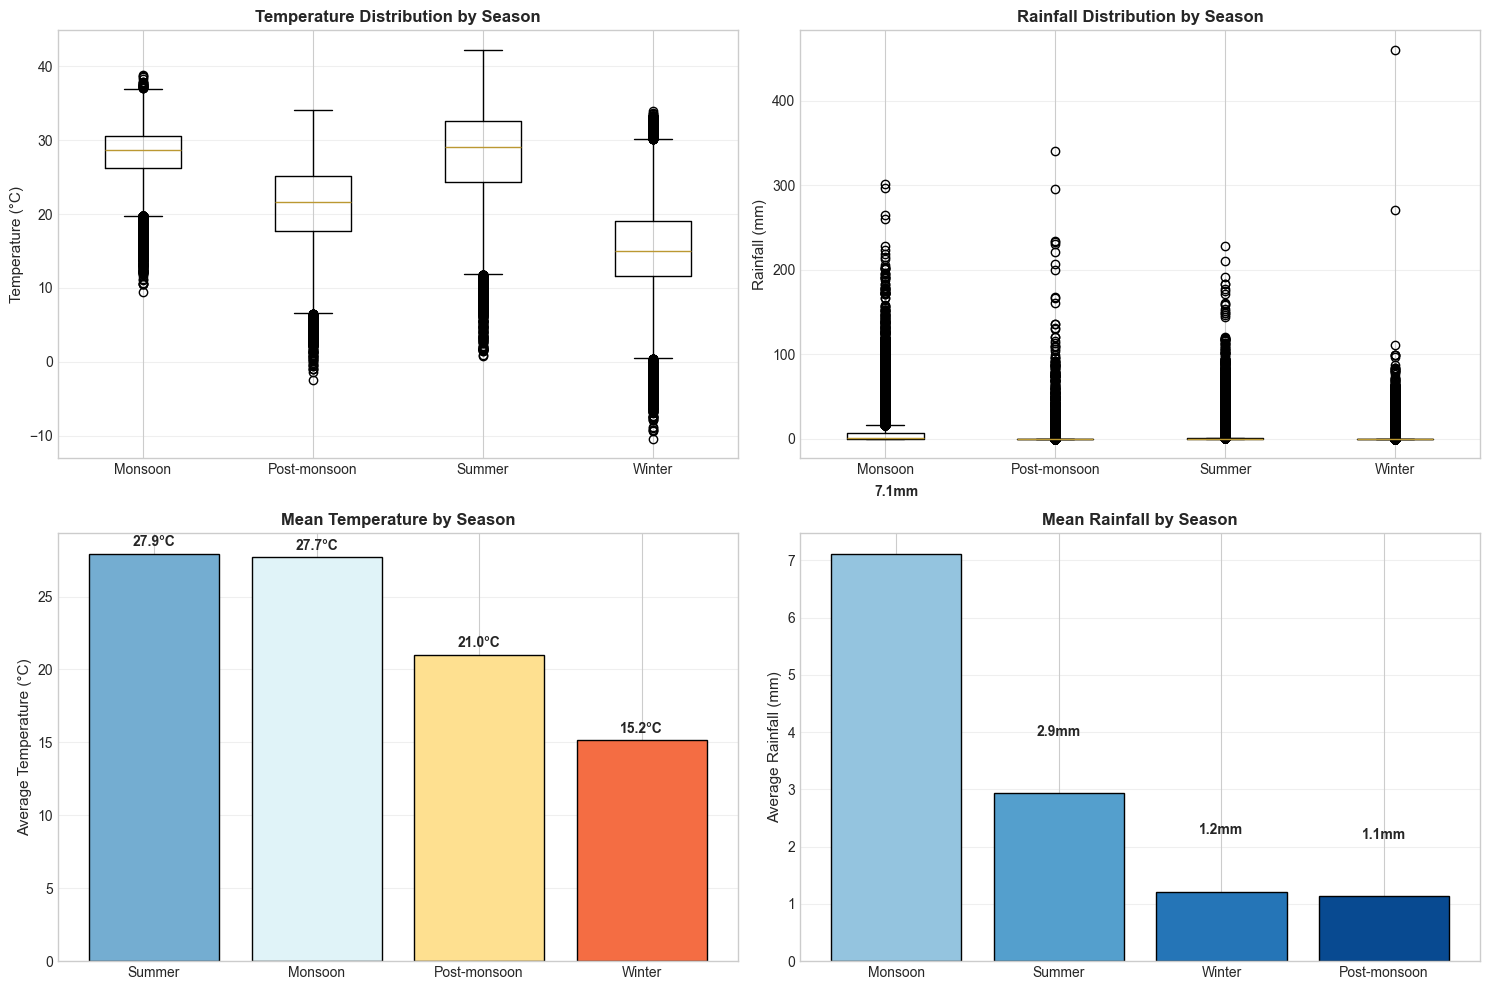

✓ Seasonal climate patterns visualized


In [8]:
# 7.1 Average Temperature and Rainfall by Season
print("\n" + "="*80)
print("7.1 SEASONAL CLIMATE OVERVIEW")
print("="*80)

# Season-wise statistics
seasonal_stats = df.groupby('season').agg({
    'avg_temp': ['mean', 'min', 'max', 'std'],
    'rainfall': ['mean', 'sum', 'max'],
    'wind_speed': 'mean',
    'air_pressure': 'mean'
}).round(2)

seasonal_stats.columns = ['_'.join(col).strip() for col in seasonal_stats.columns.values]
seasonal_stats = seasonal_stats.sort_values('avg_temp_mean', ascending=False)

print("\n✓ Season-wise Climate Statistics:")
print(seasonal_stats)

# Visualize seasonal patterns
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Seasonal temperature distribution
seasons = df['season'].unique()
seasonal_data = df.groupby('season')['avg_temp'].apply(list).to_dict()
axes[0, 0].boxplot([seasonal_data[s] for s in sorted(seasonal_data.keys())], 
                    labels=sorted(seasonal_data.keys()))
axes[0, 0].set_ylabel('Temperature (°C)', fontsize=11)
axes[0, 0].set_title('Temperature Distribution by Season', fontsize=12, fontweight='bold')
axes[0, 0].grid(alpha=0.3, axis='y')

# Seasonal rainfall distribution
rainfall_data = df.groupby('season')['rainfall'].apply(list).to_dict()
axes[0, 1].boxplot([rainfall_data[s] for s in sorted(rainfall_data.keys())], 
                    labels=sorted(rainfall_data.keys()))
axes[0, 1].set_ylabel('Rainfall (mm)', fontsize=11)
axes[0, 1].set_title('Rainfall Distribution by Season', fontsize=12, fontweight='bold')
axes[0, 1].grid(alpha=0.3, axis='y')

# Average temperature by season (bar chart)
season_avg_temp = df.groupby('season')['avg_temp'].mean().sort_values(ascending=False)
colors_temp = plt.cm.RdYlBu_r(np.linspace(0.2, 0.8, len(season_avg_temp)))
axes[1, 0].bar(season_avg_temp.index, season_avg_temp.values, color=colors_temp, edgecolor='black')
axes[1, 0].set_ylabel('Average Temperature (°C)', fontsize=11)
axes[1, 0].set_title('Mean Temperature by Season', fontsize=12, fontweight='bold')
axes[1, 0].grid(alpha=0.3, axis='y')
for i, v in enumerate(season_avg_temp.values):
    axes[1, 0].text(i, v + 0.5, f'{v:.1f}°C', ha='center', fontweight='bold')

# Average rainfall by season (bar chart)
season_avg_rainfall = df.groupby('season')['rainfall'].mean().sort_values(ascending=False)
colors_rain = plt.cm.Blues(np.linspace(0.4, 0.9, len(season_avg_rainfall)))
axes[1, 1].bar(season_avg_rainfall.index, season_avg_rainfall.values, color=colors_rain, edgecolor='black')
axes[1, 1].set_ylabel('Average Rainfall (mm)', fontsize=11)
axes[1, 1].set_title('Mean Rainfall by Season', fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3, axis='y')
for i, v in enumerate(season_avg_rainfall.values):
    axes[1, 1].text(i, v + 1, f'{v:.1f}mm', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ Seasonal climate patterns visualized")



7.2 MONTHLY TEMPERATURE TRENDS

✓ Monthly Climate Statistics:
       avg_temp_mean  avg_temp_min  avg_temp_max  avg_temp_std  rainfall_mean
Month                                                                        
1              11.89          -9.3          23.1          4.47           1.36
2              15.39         -10.4          28.1          5.35           1.28
3              20.53          -6.8          33.9          5.92           1.68
4              25.50           0.8          38.6          6.27           1.80
5              28.52           2.2          41.6          6.38           2.50
6              29.76           6.3          42.2          5.61           4.52
7              28.34          12.2          38.8          4.26           9.35
8              27.72          11.9          36.0          3.95           7.30
9              26.97           9.5          36.7          4.21           4.60
10             23.67           1.3          34.1          4.94           1.82
1

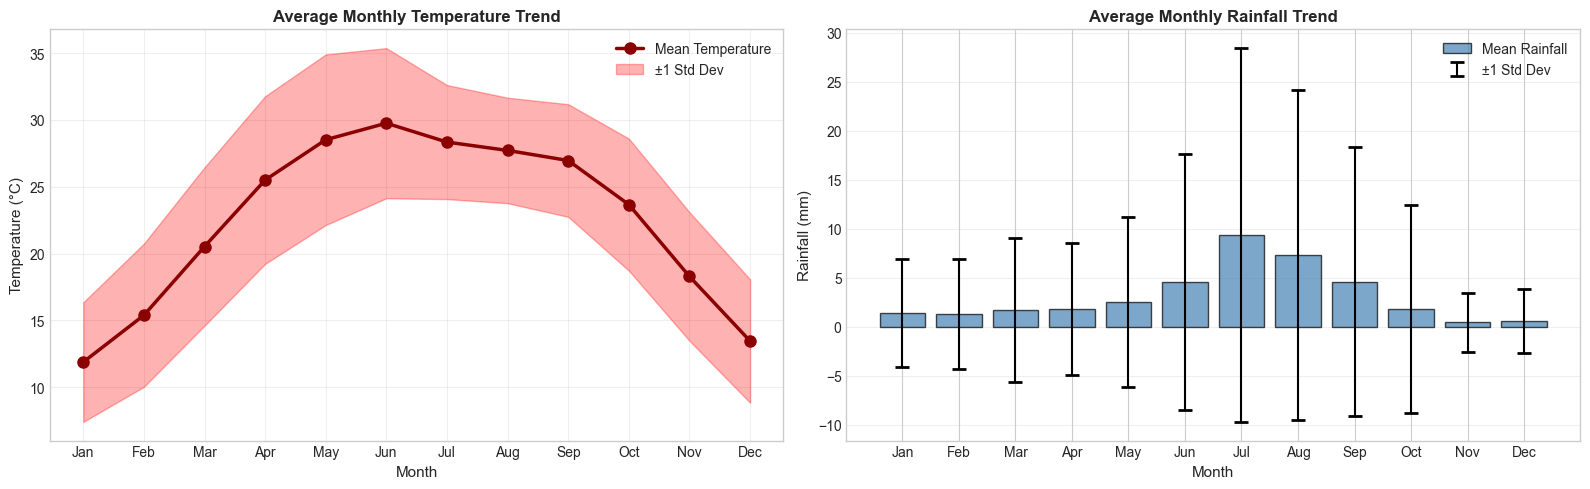

✓ Monthly temperature and rainfall trends visualized


In [9]:
# 7.2 Monthly Temperature Trends
print("\n" + "="*80)
print("7.2 MONTHLY TEMPERATURE TRENDS")
print("="*80)

# Monthly statistics
monthly_stats = df.groupby('Month').agg({
    'avg_temp': ['mean', 'min', 'max', 'std'],
    'rainfall': 'mean'
}).round(2)

monthly_stats.columns = ['_'.join(col).strip() for col in monthly_stats.columns.values]

print("\n✓ Monthly Climate Statistics:")
print(monthly_stats)

# Visualize monthly trends
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Monthly temperature trend
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_temp = df.groupby('Month')['avg_temp'].mean()
monthly_temp_std = df.groupby('Month')['avg_temp'].std()

axes[0].plot(monthly_temp.index, monthly_temp.values, marker='o', linewidth=2.5, 
             markersize=8, color='darkred', label='Mean Temperature')
axes[0].fill_between(monthly_temp.index, 
                      monthly_temp.values - monthly_temp_std.values,
                      monthly_temp.values + monthly_temp_std.values,
                      alpha=0.3, color='red', label='±1 Std Dev')
axes[0].set_xlabel('Month', fontsize=11)
axes[0].set_ylabel('Temperature (°C)', fontsize=11)
axes[0].set_title('Average Monthly Temperature Trend', fontsize=12, fontweight='bold')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(month_names)
axes[0].grid(alpha=0.3)
axes[0].legend()

# Monthly rainfall trend
monthly_rainfall = df.groupby('Month')['rainfall'].mean()
monthly_rainfall_std = df.groupby('Month')['rainfall'].std()

axes[1].bar(monthly_rainfall.index, monthly_rainfall.values, color='steelblue', 
            edgecolor='black', alpha=0.7, label='Mean Rainfall')
axes[1].errorbar(monthly_rainfall.index, monthly_rainfall.values, 
                 yerr=monthly_rainfall_std.values, fmt='none', color='black', 
                 capsize=5, capthick=2, label='±1 Std Dev')
axes[1].set_xlabel('Month', fontsize=11)
axes[1].set_ylabel('Rainfall (mm)', fontsize=11)
axes[1].set_title('Average Monthly Rainfall Trend', fontsize=12, fontweight='bold')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(month_names)
axes[1].grid(alpha=0.3, axis='y')
axes[1].legend()

plt.tight_layout()
plt.show()

print("✓ Monthly temperature and rainfall trends visualized")



7.3 SEASONAL VARIATION BY STATE

✓ Average Temperature by State and Season:
season  Monsoon  Post-monsoon  Summer  Winter
state                                        
AR        28.29         24.33   25.77   19.89
AS        29.13         25.09   26.40   20.08
CH        29.20         21.56   29.93   15.85
DL        30.43         23.59   32.22   17.35
HP        24.48         17.19   22.85   11.86
HR        29.21         22.03   30.39   15.52
JK        24.00         13.84   20.18    7.44
MP        29.51         23.55   33.03   18.11
PB        29.66         21.78   30.05   14.99
RJ        30.20         24.56   32.72   18.58

✓ Average Rainfall by State and Season:
season  Monsoon  Post-monsoon  Summer  Winter
state                                        
AR        23.24          5.37   16.80    2.29
AS        14.06          3.56   12.68    1.44
CH         6.52          0.56    1.71    1.07
DL         5.66          0.43    1.26    0.80
HP         8.26          1.13    3.27    2.68
HR      

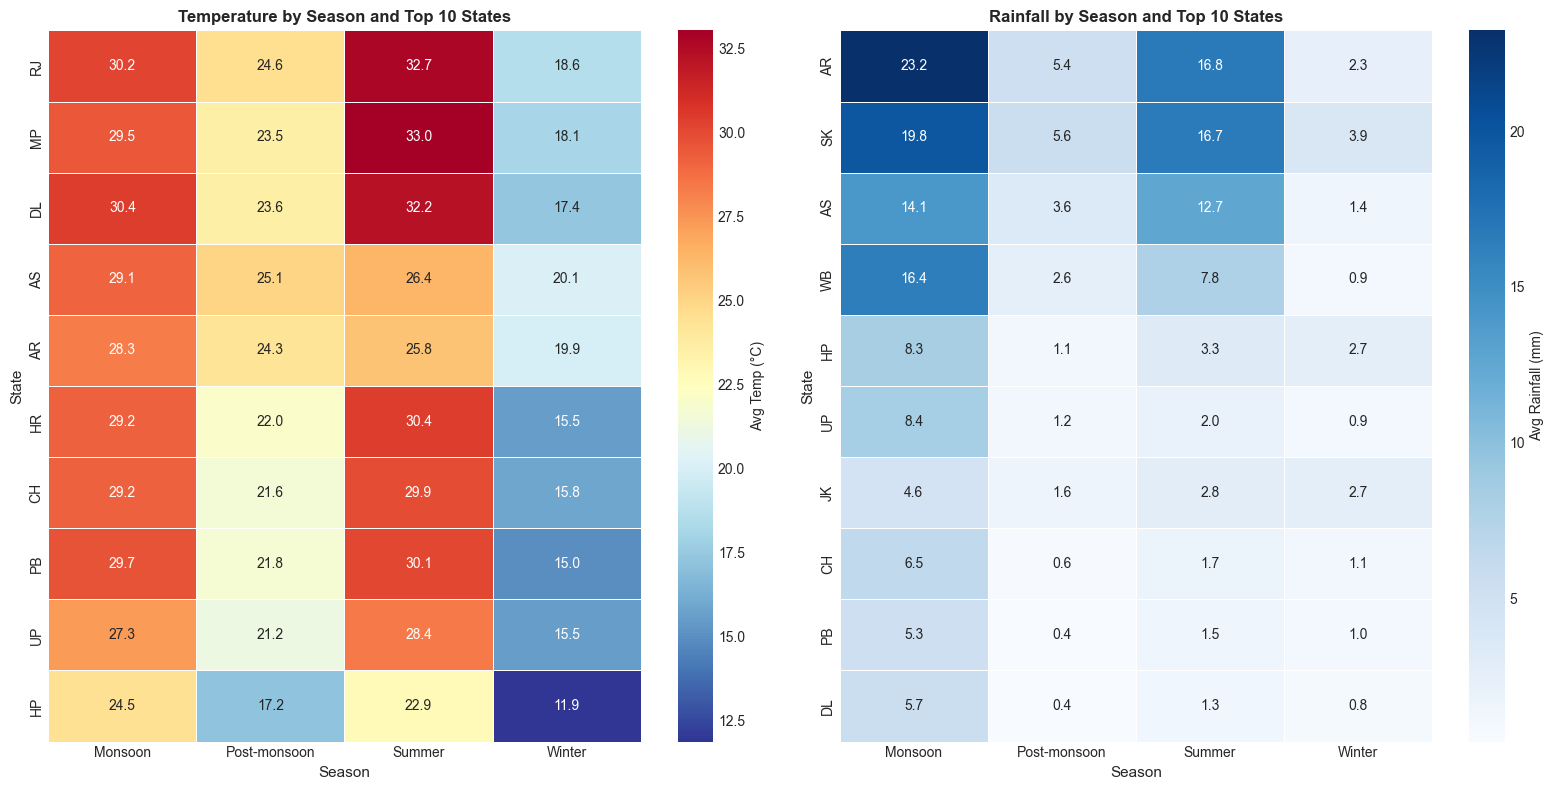

✓ Seasonal variation by state visualized


In [10]:
# 7.3 Seasonal Variation by State
print("\n" + "="*80)
print("7.3 SEASONAL VARIATION BY STATE")
print("="*80)

# State-season interaction
state_season_temp = df.pivot_table(values='avg_temp', index='state', columns='season', aggfunc='mean')
state_season_rainfall = df.pivot_table(values='rainfall', index='state', columns='season', aggfunc='mean')

print("\n✓ Average Temperature by State and Season:")
print(state_season_temp.round(2).head(10))

print("\n✓ Average Rainfall by State and Season:")
print(state_season_rainfall.round(2).head(10))

# Visualize top 10 states with seasonal variation
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Temperature heatmap
top_states_temp = df.groupby('state')['avg_temp'].mean().nlargest(10).index
state_season_temp_top = state_season_temp.loc[top_states_temp]
sns.heatmap(state_season_temp_top, annot=True, fmt='.1f', cmap='RdYlBu_r', 
            cbar_kws={'label': 'Avg Temp (°C)'}, ax=axes[0], linewidths=0.5)
axes[0].set_title('Temperature by Season and Top 10 States', fontsize=12, fontweight='bold')
axes[0].set_ylabel('State', fontsize=11)
axes[0].set_xlabel('Season', fontsize=11)

# Rainfall heatmap
top_states_rain = df.groupby('state')['rainfall'].mean().nlargest(10).index
state_season_rainfall_top = state_season_rainfall.loc[top_states_rain]
sns.heatmap(state_season_rainfall_top, annot=True, fmt='.1f', cmap='Blues', 
            cbar_kws={'label': 'Avg Rainfall (mm)'}, ax=axes[1], linewidths=0.5)
axes[1].set_title('Rainfall by Season and Top 10 States', fontsize=12, fontweight='bold')
axes[1].set_ylabel('State', fontsize=11)
axes[1].set_xlabel('Season', fontsize=11)

plt.tight_layout()
plt.show()

print("✓ Seasonal variation by state visualized")


---

# Section 8: ⚠️ Anomaly Analysis

**Objective:** Detect and analyze extreme weather events and anomalies

### Analysis Components:
- Unusual hot/cold events (local and global)
- Heavy rainfall events frequency
- Pressure anomaly analysis
- Top anomaly-prone stations



8.1 TEMPERATURE ANOMALY ANALYSIS

✓ Temperature Anomaly Counts:
  - Unusual_Hot_Global: 1,246 events (0.83%)
  - Unusual_Cold_Global: 1,246 events (0.83%)
  - Unusual_Hot_Local: 12,180 events (8.12%)
  - Unusual_Cold_Local: 12,129 events (8.09%)


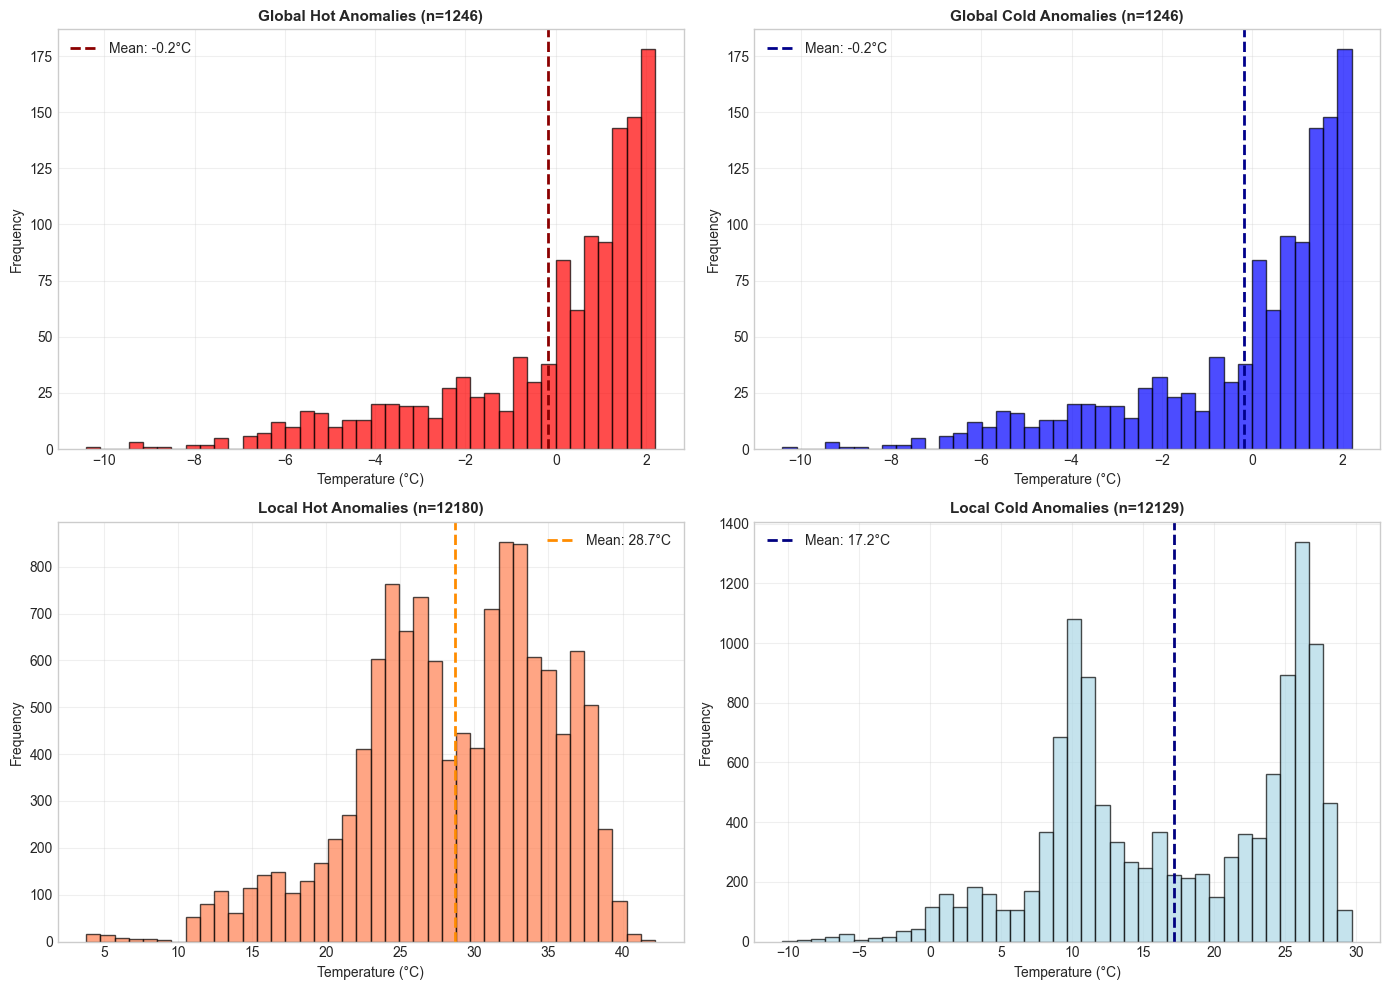

✓ Temperature anomalies visualized


In [11]:
# 8.1 Temperature Anomaly Analysis
print("\n" + "="*80)
print("8.1 TEMPERATURE ANOMALY ANALYSIS")
print("="*80)

# Count anomalies
anomaly_counts = {
    'Unusual_Hot_Global': (df['Unusual_Hot_Global'] == 1).sum(),
    'Unusual_Cold_Global': (df['Unusual_Cold_Global'] == 1).sum(),
    'Unusual_Hot_Local': (df['Unusual_Hot_Local'] == 1).sum(),
    'Unusual_Cold_Local': (df['Unusual_Cold_Local'] == 1).sum()
}

anomaly_pcts = {k: v/len(df)*100 for k, v in anomaly_counts.items()}

print("\n✓ Temperature Anomaly Counts:")
for anomaly_type, count in anomaly_counts.items():
    pct = anomaly_pcts[anomaly_type]
    print(f"  - {anomaly_type}: {count:,} events ({pct:.2f}%)")

# Visualize anomaly distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Global hot anomalies
ax = axes[0, 0]
global_hot = df[df['Unusual_Hot_Global'] == 1]['avg_temp'].values
ax.hist(global_hot, bins=40, color='red', edgecolor='black', alpha=0.7)
ax.axvline(global_hot.mean(), color='darkred', linestyle='--', linewidth=2, label=f'Mean: {global_hot.mean():.1f}°C')
ax.set_xlabel('Temperature (°C)', fontsize=10)
ax.set_ylabel('Frequency', fontsize=10)
ax.set_title(f'Global Hot Anomalies (n={len(global_hot)})', fontsize=11, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Global cold anomalies
ax = axes[0, 1]
global_cold = df[df['Unusual_Cold_Global'] == 1]['avg_temp'].values
ax.hist(global_cold, bins=40, color='blue', edgecolor='black', alpha=0.7)
ax.axvline(global_cold.mean(), color='darkblue', linestyle='--', linewidth=2, label=f'Mean: {global_cold.mean():.1f}°C')
ax.set_xlabel('Temperature (°C)', fontsize=10)
ax.set_ylabel('Frequency', fontsize=10)
ax.set_title(f'Global Cold Anomalies (n={len(global_cold)})', fontsize=11, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Local hot anomalies
ax = axes[1, 0]
local_hot = df[df['Unusual_Hot_Local'] == 1]['avg_temp'].values
ax.hist(local_hot, bins=40, color='coral', edgecolor='black', alpha=0.7)
ax.axvline(local_hot.mean(), color='darkorange', linestyle='--', linewidth=2, label=f'Mean: {local_hot.mean():.1f}°C')
ax.set_xlabel('Temperature (°C)', fontsize=10)
ax.set_ylabel('Frequency', fontsize=10)
ax.set_title(f'Local Hot Anomalies (n={len(local_hot)})', fontsize=11, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Local cold anomalies
ax = axes[1, 1]
local_cold = df[df['Unusual_Cold_Local'] == 1]['avg_temp'].values
ax.hist(local_cold, bins=40, color='lightblue', edgecolor='black', alpha=0.7)
ax.axvline(local_cold.mean(), color='navy', linestyle='--', linewidth=2, label=f'Mean: {local_cold.mean():.1f}°C')
ax.set_xlabel('Temperature (°C)', fontsize=10)
ax.set_ylabel('Frequency', fontsize=10)
ax.set_title(f'Local Cold Anomalies (n={len(local_cold)})', fontsize=11, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Temperature anomalies visualized")



8.2 RAINFALL & PRESSURE ANOMALY ANALYSIS

✓ Rainfall Event Counts:
  - Heavy Rainfall Events: 27,492 (18.33%)
  - Light Rainfall Events: 0 (0.00%)
  - No Rainfall Days: 104,949 (69.97%)
  - Pressure Anomalies: 8,097 (5.40%)


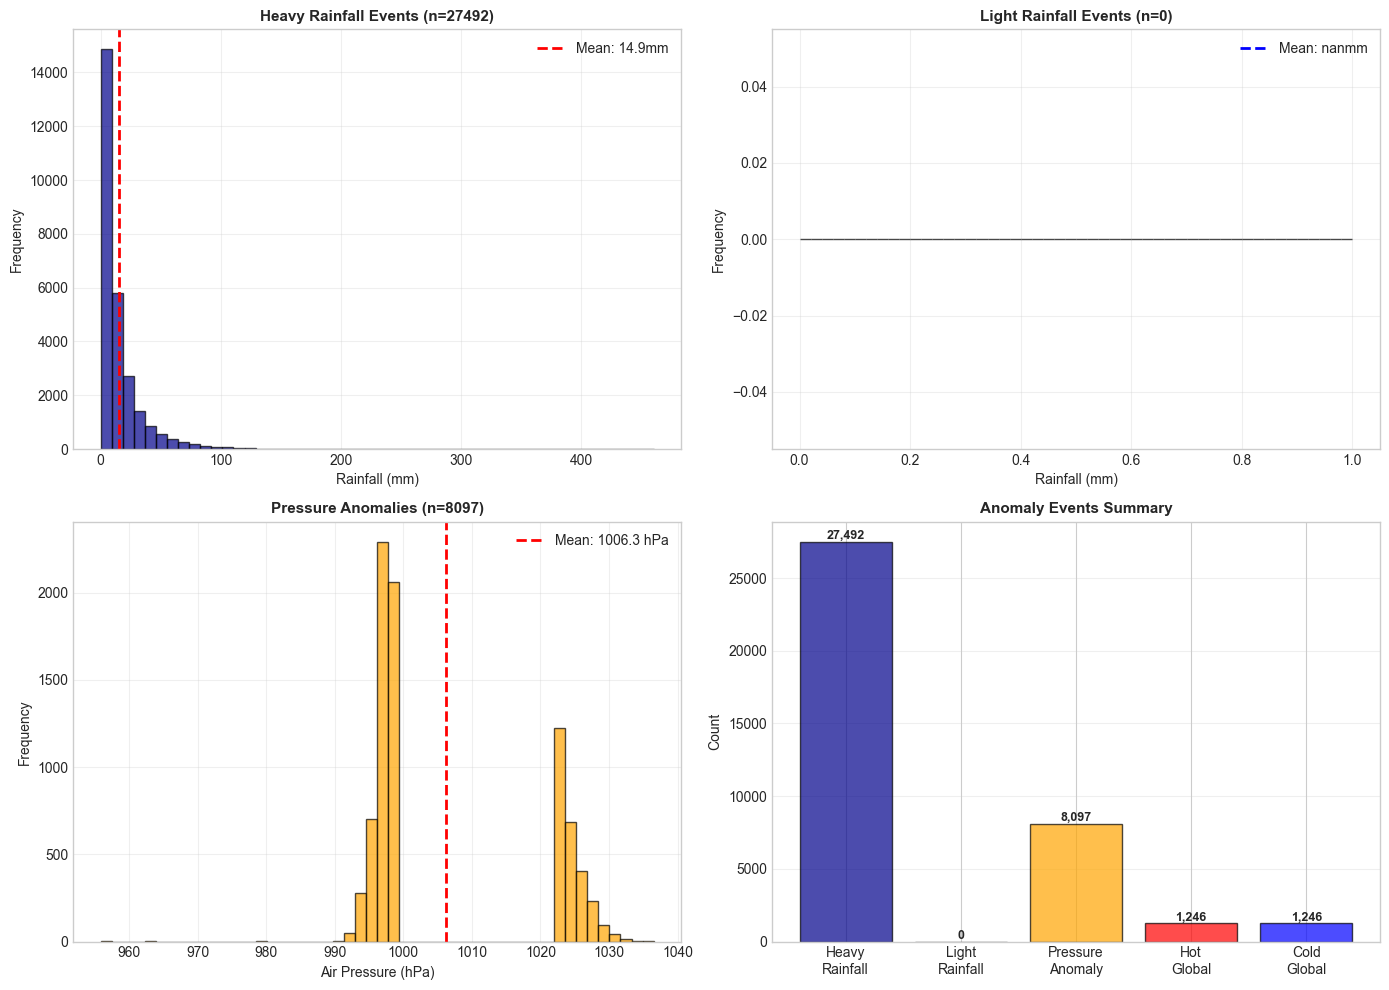

✓ Rainfall and pressure anomalies visualized


In [12]:
# 8.2 Rainfall and Pressure Anomaly Analysis
print("\n" + "="*80)
print("8.2 RAINFALL & PRESSURE ANOMALY ANALYSIS")
print("="*80)

# Rainfall anomalies
heavy_rainfall_count = (df['Heavy_Rainfall'] == 1).sum()
light_rainfall_count = (df['Light_Rainfall'] == 1).sum()
no_rainfall_days = (df['rainfall'] == 0).sum()

print("\n✓ Rainfall Event Counts:")
print(f"  - Heavy Rainfall Events: {heavy_rainfall_count:,} ({heavy_rainfall_count/len(df)*100:.2f}%)")
print(f"  - Light Rainfall Events: {light_rainfall_count:,} ({light_rainfall_count/len(df)*100:.2f}%)")
print(f"  - No Rainfall Days: {no_rainfall_days:,} ({no_rainfall_days/len(df)*100:.2f}%)")

# Pressure anomalies
pressure_anomaly_count = (df['Pressure_Anomaly'] == 1).sum()
print(f"  - Pressure Anomalies: {pressure_anomaly_count:,} ({pressure_anomaly_count/len(df)*100:.2f}%)")

# Visualize anomalies
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Heavy Rainfall Events
ax = axes[0, 0]
heavy_rain_vals = df[df['Heavy_Rainfall'] == 1]['rainfall'].values
ax.hist(heavy_rain_vals, bins=50, color='darkblue', edgecolor='black', alpha=0.7)
ax.axvline(heavy_rain_vals.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {heavy_rain_vals.mean():.1f}mm')
ax.set_xlabel('Rainfall (mm)', fontsize=10)
ax.set_ylabel('Frequency', fontsize=10)
ax.set_title(f'Heavy Rainfall Events (n={len(heavy_rain_vals)})', fontsize=11, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Light Rainfall Events
ax = axes[0, 1]
light_rain_vals = df[df['Light_Rainfall'] == 1]['rainfall'].values
ax.hist(light_rain_vals, bins=50, color='lightblue', edgecolor='black', alpha=0.7)
ax.axvline(light_rain_vals.mean(), color='blue', linestyle='--', linewidth=2, label=f'Mean: {light_rain_vals.mean():.1f}mm')
ax.set_xlabel('Rainfall (mm)', fontsize=10)
ax.set_ylabel('Frequency', fontsize=10)
ax.set_title(f'Light Rainfall Events (n={len(light_rain_vals)})', fontsize=11, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Pressure Anomalies
ax = axes[1, 0]
pressure_anomaly_vals = df[df['Pressure_Anomaly'] == 1]['air_pressure'].values
ax.hist(pressure_anomaly_vals, bins=50, color='orange', edgecolor='black', alpha=0.7)
ax.axvline(pressure_anomaly_vals.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {pressure_anomaly_vals.mean():.1f} hPa')
ax.set_xlabel('Air Pressure (hPa)', fontsize=10)
ax.set_ylabel('Frequency', fontsize=10)
ax.set_title(f'Pressure Anomalies (n={len(pressure_anomaly_vals)})', fontsize=11, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Anomaly Summary
ax = axes[1, 1]
anomaly_types = ['Heavy\nRainfall', 'Light\nRainfall', 'Pressure\nAnomaly', 'Hot\nGlobal', 'Cold\nGlobal']
anomaly_values = [heavy_rainfall_count, light_rainfall_count, pressure_anomaly_count, 
                   anomaly_counts['Unusual_Hot_Global'], anomaly_counts['Unusual_Cold_Global']]
colors_anom = ['darkblue', 'lightblue', 'orange', 'red', 'blue']
bars = ax.bar(anomaly_types, anomaly_values, color=colors_anom, edgecolor='black', alpha=0.7)
ax.set_ylabel('Count', fontsize=10)
ax.set_title('Anomaly Events Summary', fontsize=11, fontweight='bold')
ax.grid(alpha=0.3, axis='y')
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ Rainfall and pressure anomalies visualized")



8.3 TOP ANOMALY-PRONE STATIONS

✓ Top 10 Most Anomaly-Prone Stations (by total count):
             station_name  Total_Anomalies  Unusual_Hot_Global  \
58               Srinagar             5040                 585   
23                Gulmarg             2079                 480   
45        North Lakhimpur             1958                   0   
20  Dibrugarh / Mohanbari             1869                   0   
47               Pasighat             1645                   0   
0                    Agra             1614                   0   
17               Dehradun             1511                   0   
56                 Shimla             1480                  50   
29                  Jammu             1466                   0   
18               Dharmpur             1408                  14   

    Unusual_Cold_Global  Heavy_Rainfall  Records  
58                  585            1495     7388  
23                  480             582     1488  
45                    0         

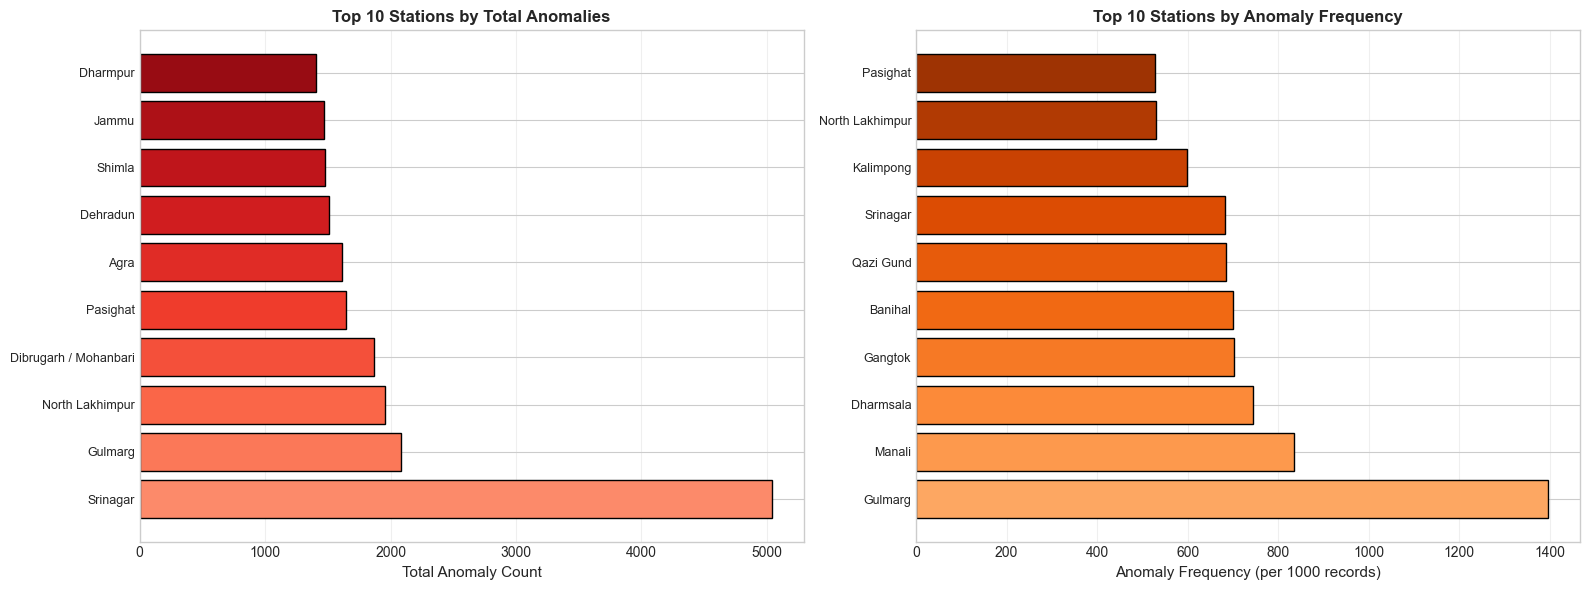

✓ Anomaly-prone stations visualized


In [13]:
# 8.3 Top Anomaly-Prone Stations
print("\n" + "="*80)
print("8.3 TOP ANOMALY-PRONE STATIONS")
print("="*80)

# Calculate anomaly scores for each station
station_anomalies = df.groupby('station_name').agg({
    'Unusual_Hot_Global': 'sum',
    'Unusual_Cold_Global': 'sum',
    'Unusual_Hot_Local': 'sum',
    'Unusual_Cold_Local': 'sum',
    'Heavy_Rainfall': 'sum',
    'Pressure_Anomaly': 'sum'
}).reset_index()

# Calculate total anomaly count
station_anomalies['Total_Anomalies'] = (station_anomalies['Unusual_Hot_Global'] + 
                                         station_anomalies['Unusual_Cold_Global'] +
                                         station_anomalies['Unusual_Hot_Local'] + 
                                         station_anomalies['Unusual_Cold_Local'] +
                                         station_anomalies['Heavy_Rainfall'] + 
                                         station_anomalies['Pressure_Anomaly'])

# Calculate anomaly frequency (anomalies per 1000 records)
station_record_counts = df.groupby('station_name').size().reset_index(name='Records')
station_anomalies = station_anomalies.merge(station_record_counts, on='station_name')
station_anomalies['Anomaly_Frequency'] = (station_anomalies['Total_Anomalies'] / station_anomalies['Records']) * 1000

# Sort by total anomalies
station_anomalies_sorted = station_anomalies.sort_values('Total_Anomalies', ascending=False)

print("\n✓ Top 10 Most Anomaly-Prone Stations (by total count):")
print(station_anomalies_sorted[['station_name', 'Total_Anomalies', 'Unusual_Hot_Global', 
                                 'Unusual_Cold_Global', 'Heavy_Rainfall', 'Records']].head(10))

# Sort by frequency
station_anomalies_freq = station_anomalies.sort_values('Anomaly_Frequency', ascending=False)

print("\n✓ Top 10 Most Anomaly-Prone Stations (by frequency per 1000 records):")
print(station_anomalies_freq[['station_name', 'Anomaly_Frequency', 'Total_Anomalies', 'Records']].head(10))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top stations by total anomalies
top_10_total = station_anomalies_sorted.head(10)
ax = axes[0]
x_pos = np.arange(len(top_10_total))
colors_grad = plt.cm.Reds(np.linspace(0.4, 0.9, len(top_10_total)))
ax.barh(x_pos, top_10_total['Total_Anomalies'].values, color=colors_grad, edgecolor='black')
ax.set_yticks(x_pos)
ax.set_yticklabels(top_10_total['station_name'].values, fontsize=9)
ax.set_xlabel('Total Anomaly Count', fontsize=11)
ax.set_title('Top 10 Stations by Total Anomalies', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3, axis='x')

# Top stations by frequency
top_10_freq = station_anomalies_freq.head(10)
ax = axes[1]
x_pos = np.arange(len(top_10_freq))
colors_grad = plt.cm.Oranges(np.linspace(0.4, 0.9, len(top_10_freq)))
ax.barh(x_pos, top_10_freq['Anomaly_Frequency'].values, color=colors_grad, edgecolor='black')
ax.set_yticks(x_pos)
ax.set_yticklabels(top_10_freq['station_name'].values, fontsize=9)
ax.set_xlabel('Anomaly Frequency (per 1000 records)', fontsize=11)
ax.set_title('Top 10 Stations by Anomaly Frequency', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("✓ Anomaly-prone stations visualized")


---

# Section 9: 🗺️ Geographical Insights

**Objective:** Add spatial intelligence by analyzing geographical patterns

### Analysis Components:
- Hottest states and districts
- Wettest regions
- Elevation vs temperature analysis
- Riskiest stations (high anomalies)
- Spatial distribution patterns



9.1 STATE-WISE RANKINGS

✓ Top 10 Hottest States:
       avg_temp  rainfall
state                    
RJ        25.87      1.19
MP        25.66      1.66
DL        25.30      2.06
AS        24.72      7.71
AR        24.01     11.20
HR        23.60      1.85
CH        23.50      2.49
PB        23.39      2.08
UP        22.49      3.08
HP        18.51      3.94

✓ Top 10 Coldest States:
       avg_temp  rainfall
state                    
AS        24.72      7.71
AR        24.01     11.20
HR        23.60      1.85
CH        23.50      2.49
PB        23.39      2.08
UP        22.49      3.08
HP        18.51      3.94
WB        17.53      6.96
JK        15.73      3.04
SK        13.54     11.15

✓ Top 10 Wettest States:
       rainfall  avg_temp
state                    
AR        11.20     24.01
SK        11.15     13.54
AS         7.71     24.72
WB         6.96     17.53
HP         3.94     18.51
UP         3.08     22.49
JK         3.04     15.73
CH         2.49     23.50
PB         2.

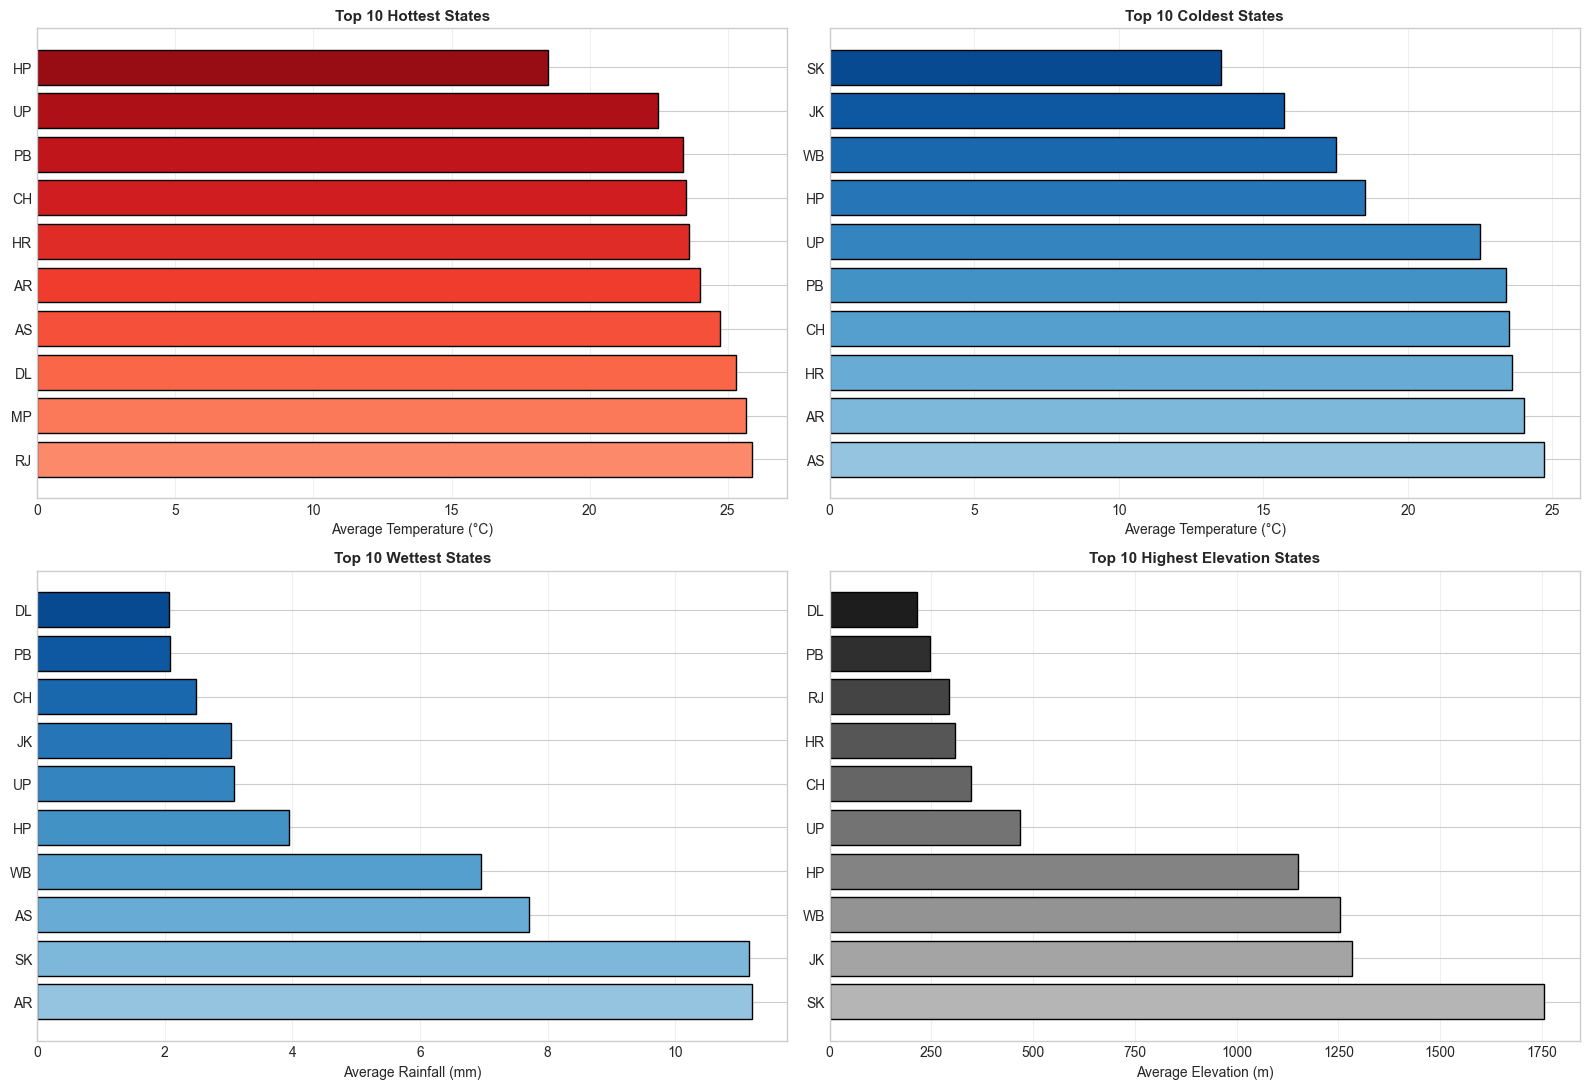

✓ State rankings visualized


In [14]:
# 9.1 State-wise Temperature and Rainfall Rankings
print("\n" + "="*80)
print("9.1 STATE-WISE RANKINGS")
print("="*80)

# Hottest, coldest, wettest, driest states
state_rankings = df.groupby('state').agg({
    'avg_temp': 'mean',
    'rainfall': 'mean',
    'elevation': 'mean',
    'wind_speed': 'mean'
}).round(2)

state_rankings_sorted_hot = state_rankings.sort_values('avg_temp', ascending=False)
state_rankings_sorted_wet = state_rankings.sort_values('rainfall', ascending=False)
state_rankings_sorted_elev = state_rankings.sort_values('elevation', ascending=False)

print("\n✓ Top 10 Hottest States:")
print(state_rankings_sorted_hot[['avg_temp', 'rainfall']].head(10))

print("\n✓ Top 10 Coldest States:")
print(state_rankings_sorted_hot[['avg_temp', 'rainfall']].tail(10))

print("\n✓ Top 10 Wettest States:")
print(state_rankings_sorted_wet[['rainfall', 'avg_temp']].head(10))

print("\n✓ Top 10 Highest Elevation States:")
print(state_rankings_sorted_elev[['elevation', 'avg_temp']].head(10))

# Visualize rankings
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# Hottest states
ax = axes[0, 0]
top_hot = state_rankings_sorted_hot.head(10)
colors_hot = plt.cm.Reds(np.linspace(0.4, 0.9, len(top_hot)))
ax.barh(range(len(top_hot)), top_hot['avg_temp'].values, color=colors_hot, edgecolor='black')
ax.set_yticks(range(len(top_hot)))
ax.set_yticklabels(top_hot.index, fontsize=10)
ax.set_xlabel('Average Temperature (°C)', fontsize=10)
ax.set_title('Top 10 Hottest States', fontsize=11, fontweight='bold')
ax.grid(alpha=0.3, axis='x')

# Coldest states
ax = axes[0, 1]
top_cold = state_rankings_sorted_hot.tail(10)
colors_cold = plt.cm.Blues(np.linspace(0.4, 0.9, len(top_cold)))
ax.barh(range(len(top_cold)), top_cold['avg_temp'].values, color=colors_cold, edgecolor='black')
ax.set_yticks(range(len(top_cold)))
ax.set_yticklabels(top_cold.index, fontsize=10)
ax.set_xlabel('Average Temperature (°C)', fontsize=10)
ax.set_title('Top 10 Coldest States', fontsize=11, fontweight='bold')
ax.grid(alpha=0.3, axis='x')

# Wettest states
ax = axes[1, 0]
top_wet = state_rankings_sorted_wet.head(10)
colors_wet = plt.cm.Blues(np.linspace(0.4, 0.9, len(top_wet)))
ax.barh(range(len(top_wet)), top_wet['rainfall'].values, color=colors_wet, edgecolor='black')
ax.set_yticks(range(len(top_wet)))
ax.set_yticklabels(top_wet.index, fontsize=10)
ax.set_xlabel('Average Rainfall (mm)', fontsize=10)
ax.set_title('Top 10 Wettest States', fontsize=11, fontweight='bold')
ax.grid(alpha=0.3, axis='x')

# Highest elevation states
ax = axes[1, 1]
top_elev = state_rankings_sorted_elev.head(10)
colors_elev = plt.cm.Greys(np.linspace(0.4, 0.9, len(top_elev)))
ax.barh(range(len(top_elev)), top_elev['elevation'].values, color=colors_elev, edgecolor='black')
ax.set_yticks(range(len(top_elev)))
ax.set_yticklabels(top_elev.index, fontsize=10)
ax.set_xlabel('Average Elevation (m)', fontsize=10)
ax.set_title('Top 10 Highest Elevation States', fontsize=11, fontweight='bold')
ax.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("✓ State rankings visualized")



9.2 DISTRICT-WISE CLIMATE INSIGHTS

✓ Top 10 Wettest Districts:
            rainfall  avg_temp state
district                            
East Siang     11.20     24.01    AR
Gangtok        11.15     13.54    SK
Lakhimpur       8.91     24.69    AS
Kalimpong       7.90     23.32    WB
Dibrugarh       6.51     24.74    AS
Darjeeling      6.31     13.50    WB
Kangra          5.63     16.62    HP
Kullu           5.33     21.92    HP
Dehradun        5.12     21.79    UP
Anantnag        4.27     20.75    JK

✓ Top 10 Hottest Districts:
            avg_temp  rainfall state
district                            
Jaisalmer      27.15      0.86    RJ
Jodhpur        26.69      1.01    RJ
Bikaner        26.62      0.78    RJ
Jaipur         26.17      1.49    RJ
Gwalior        25.66      1.66    MP
Churu          25.53      1.12    RJ
Ajmer          25.47      1.71    RJ
New Delhi      25.30      2.06    DL
Rohtak         25.11      1.80    HR
Ganganagar     24.96      0.74    RJ


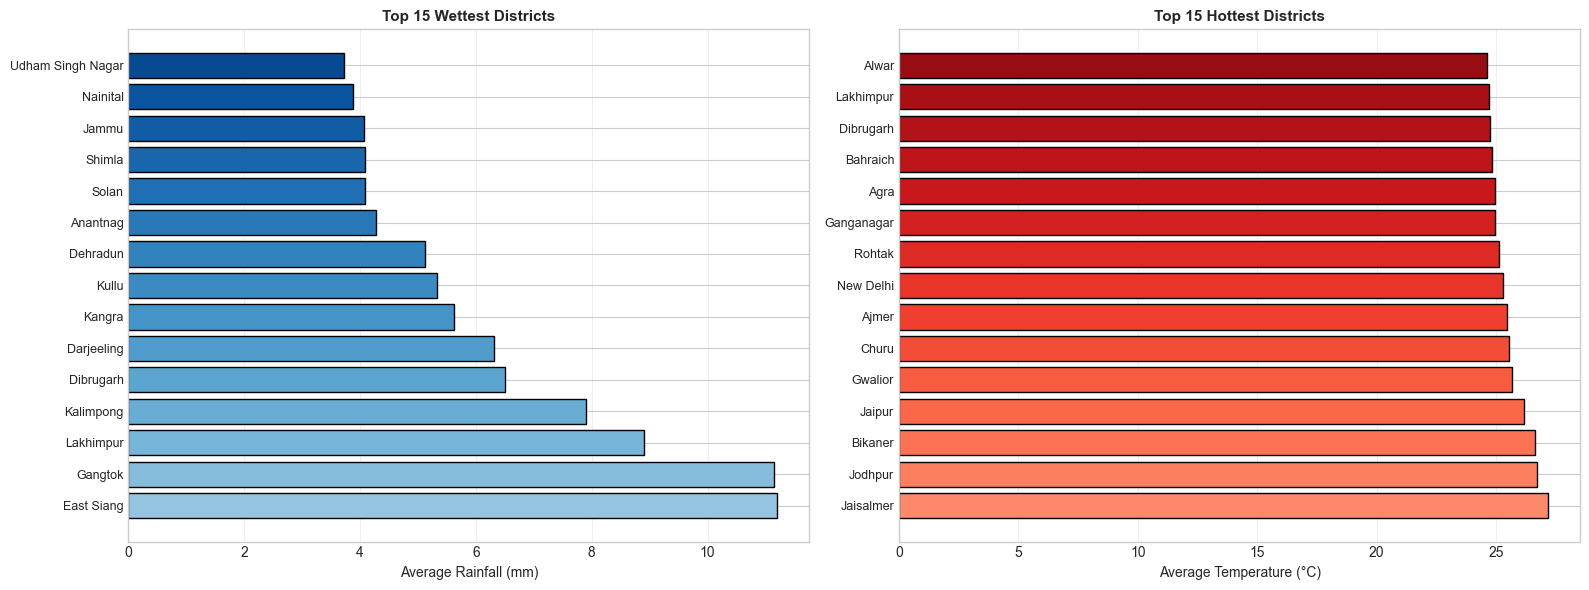

✓ District-wise insights visualized


In [15]:
# 9.2 District-wise Insights
print("\n" + "="*80)
print("9.2 DISTRICT-WISE CLIMATE INSIGHTS")
print("="*80)

# District analysis
district_stats = df.groupby('district').agg({
    'avg_temp': 'mean',
    'rainfall': 'mean',
    'elevation': 'mean',
    'state': 'first'
}).round(2)

district_stats_sorted_wet = district_stats.sort_values('rainfall', ascending=False)
district_stats_sorted_hot = district_stats.sort_values('avg_temp', ascending=False)

print("\n✓ Top 10 Wettest Districts:")
print(district_stats_sorted_wet[['rainfall', 'avg_temp', 'state']].head(10))

print("\n✓ Top 10 Hottest Districts:")
print(district_stats_sorted_hot[['avg_temp', 'rainfall', 'state']].head(10))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Wettest districts
ax = axes[0]
top_wet_dist = district_stats_sorted_wet.head(15)
colors_wet = plt.cm.Blues(np.linspace(0.4, 0.9, len(top_wet_dist)))
ax.barh(range(len(top_wet_dist)), top_wet_dist['rainfall'].values, color=colors_wet, edgecolor='black')
ax.set_yticks(range(len(top_wet_dist)))
ax.set_yticklabels(top_wet_dist.index, fontsize=9)
ax.set_xlabel('Average Rainfall (mm)', fontsize=10)
ax.set_title('Top 15 Wettest Districts', fontsize=11, fontweight='bold')
ax.grid(alpha=0.3, axis='x')

# Hottest districts
ax = axes[1]
top_hot_dist = district_stats_sorted_hot.head(15)
colors_hot = plt.cm.Reds(np.linspace(0.4, 0.9, len(top_hot_dist)))
ax.barh(range(len(top_hot_dist)), top_hot_dist['avg_temp'].values, color=colors_hot, edgecolor='black')
ax.set_yticks(range(len(top_hot_dist)))
ax.set_yticklabels(top_hot_dist.index, fontsize=9)
ax.set_xlabel('Average Temperature (°C)', fontsize=10)
ax.set_title('Top 15 Hottest Districts', fontsize=11, fontweight='bold')
ax.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("✓ District-wise insights visualized")



9.3 ELEVATION vs TEMPERATURE ANALYSIS

✓ Correlation between Elevation and Avg Temperature: -0.471

✓ Climate Statistics by Elevation Category:
                   avg_temp       rainfall elevation
                       mean   std     mean     count
Elevation_Category                                  
<500m                 24.57  7.07     2.67    104357
500-1000m             20.54  6.45     3.57      9646
1000-1500m            16.62  6.18     5.63      1488
1500-2000m            14.42  7.15     3.83     14987
>2000m                13.37  6.48     4.22      9670


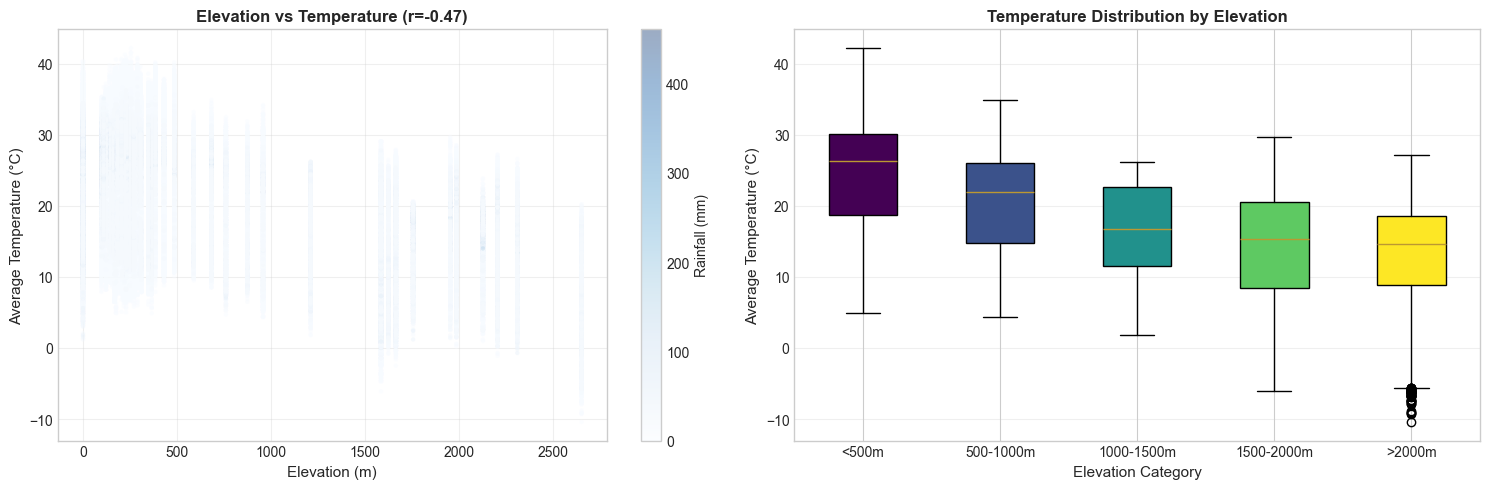

✓ Elevation vs temperature analysis visualized


In [16]:
# 9.3 Elevation vs Temperature Analysis
print("\n" + "="*80)
print("9.3 ELEVATION vs TEMPERATURE ANALYSIS")
print("="*80)

# Correlation between elevation and temperature
elev_temp_corr = df['elevation'].corr(df['avg_temp'])
print(f"\n✓ Correlation between Elevation and Avg Temperature: {elev_temp_corr:.3f}")

# Create elevation bins
df['Elevation_Category'] = pd.cut(df['elevation'], 
                                   bins=[0, 500, 1000, 1500, 2000, 3000],
                                   labels=['<500m', '500-1000m', '1000-1500m', '1500-2000m', '>2000m'])

# Statistics by elevation
elev_stats = df.groupby('Elevation_Category', observed=True).agg({
    'avg_temp': ['mean', 'std'],
    'rainfall': 'mean',
    'elevation': 'count'
}).round(2)

print("\n✓ Climate Statistics by Elevation Category:")
print(elev_stats)

# Visualize elevation vs temperature
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Scatter plot
ax = axes[0]
scatter = ax.scatter(df['elevation'], df['avg_temp'], c=df['rainfall'], 
                     cmap='Blues', alpha=0.4, s=10, edgecolors='none')
ax.set_xlabel('Elevation (m)', fontsize=11)
ax.set_ylabel('Average Temperature (°C)', fontsize=11)
ax.set_title(f'Elevation vs Temperature (r={elev_temp_corr:.2f})', fontsize=12, fontweight='bold')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Rainfall (mm)', fontsize=10)
ax.grid(alpha=0.3)

# Box plot by elevation category
ax = axes[1]
elev_temp_data = [df[df['Elevation_Category'] == cat]['avg_temp'].values 
                  for cat in ['<500m', '500-1000m', '1000-1500m', '1500-2000m', '>2000m']]
bp = ax.boxplot(elev_temp_data, labels=['<500m', '500-1000m', '1000-1500m', '1500-2000m', '>2000m'],
                patch_artist=True)
for patch, color in zip(bp['boxes'], plt.cm.viridis(np.linspace(0, 1, 5))):
    patch.set_facecolor(color)
ax.set_ylabel('Average Temperature (°C)', fontsize=11)
ax.set_xlabel('Elevation Category', fontsize=11)
ax.set_title('Temperature Distribution by Elevation', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("✓ Elevation vs temperature analysis visualized")



9.4 CLIMATE RISK ASSESSMENT

✓ Top 10 Riskiest Stations:
             station_name state  Risk_Score_Normalized Risk_Level  \
58               Srinagar    JK             100.000000     SEVERE   
23                Gulmarg    JK              50.972486       HIGH   
45        North Lakhimpur    AS              32.424099   MODERATE   
20  Dibrugarh / Mohanbari    AS              30.313093   MODERATE   
47               Pasighat    AR              27.229602   MODERATE   
56                 Shimla    HP              23.798229        LOW   
17               Dehradun    UP              21.679317        LOW   
18               Dharmpur    HP              21.521189        LOW   
34                 Manali    HP              20.896584        LOW   
29                  Jammu    JK              20.588235        LOW   

    Unusual_Hot_Global  Heavy_Rainfall  
58                 585            1495  
23                 480             582  
45                   0            1351  
20                

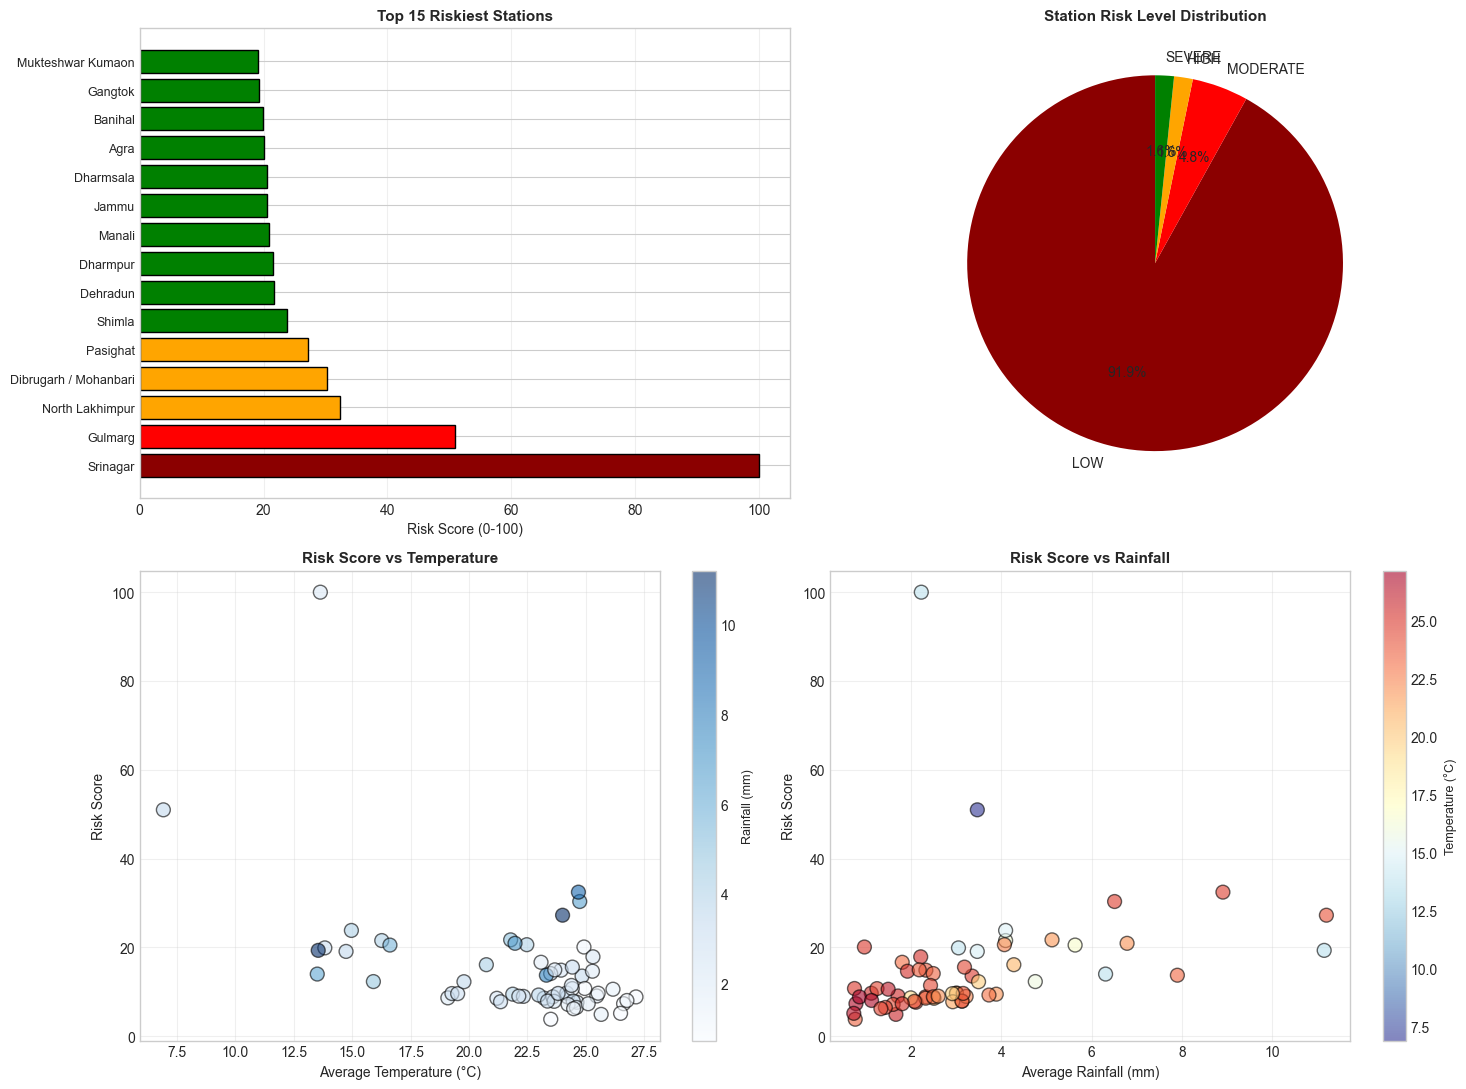

✓ Climate risk assessment visualized


In [17]:
# 9.4 Riskiest Stations and Climate Risk Scoring
print("\n" + "="*80)
print("9.4 CLIMATE RISK ASSESSMENT")
print("="*80)

# Calculate climate risk score for each station
station_risk = df.groupby('station_name').agg({
    'Unusual_Hot_Global': 'sum',
    'Unusual_Cold_Global': 'sum',
    'Heavy_Rainfall': 'sum',
    'Pressure_Anomaly': 'sum',
    'Temp_Range': 'mean',
    'avg_temp': 'mean',
    'rainfall': 'mean',
    'state': 'first'
}).reset_index()

# Calculate risk score (weighted anomaly score)
station_risk['Risk_Score'] = (
    station_risk['Unusual_Hot_Global'] * 2 + 
    station_risk['Unusual_Cold_Global'] * 2 + 
    station_risk['Heavy_Rainfall'] * 1.5 + 
    station_risk['Pressure_Anomaly'] * 1.5
)

# Normalize risk score (0-100 scale)
station_risk['Risk_Score_Normalized'] = (station_risk['Risk_Score'] / station_risk['Risk_Score'].max()) * 100

# Assign risk levels
def assign_risk_level(score):
    if score >= 75:
        return 'SEVERE'
    elif score >= 50:
        return 'HIGH'
    elif score >= 25:
        return 'MODERATE'
    else:
        return 'LOW'

station_risk['Risk_Level'] = station_risk['Risk_Score_Normalized'].apply(assign_risk_level)

# Sort by risk score
station_risk_sorted = station_risk.sort_values('Risk_Score_Normalized', ascending=False)

print("\n✓ Top 10 Riskiest Stations:")
print(station_risk_sorted[['station_name', 'state', 'Risk_Score_Normalized', 'Risk_Level', 
                            'Unusual_Hot_Global', 'Heavy_Rainfall']].head(10))

print("\n✓ Risk Level Distribution:")
print(station_risk['Risk_Level'].value_counts())

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# Top 15 riskiest stations
ax = axes[0, 0]
top_risk = station_risk_sorted.head(15)
colors_risk = []
for level in top_risk['Risk_Level']:
    if level == 'SEVERE':
        colors_risk.append('darkred')
    elif level == 'HIGH':
        colors_risk.append('red')
    elif level == 'MODERATE':
        colors_risk.append('orange')
    else:
        colors_risk.append('green')
ax.barh(range(len(top_risk)), top_risk['Risk_Score_Normalized'].values, color=colors_risk, edgecolor='black')
ax.set_yticks(range(len(top_risk)))
ax.set_yticklabels(top_risk['station_name'].values, fontsize=9)
ax.set_xlabel('Risk Score (0-100)', fontsize=10)
ax.set_title('Top 15 Riskiest Stations', fontsize=11, fontweight='bold')
ax.grid(alpha=0.3, axis='x')

# Risk level distribution pie chart
ax = axes[0, 1]
risk_counts = station_risk['Risk_Level'].value_counts()
colors_pie = ['darkred', 'red', 'orange', 'green']
ax.pie(risk_counts.values, labels=risk_counts.index, autopct='%1.1f%%',
       colors=colors_pie[:len(risk_counts)], startangle=90)
ax.set_title('Station Risk Level Distribution', fontsize=11, fontweight='bold')

# Risk score vs temperature
ax = axes[1, 0]
scatter = ax.scatter(station_risk['avg_temp'], station_risk['Risk_Score_Normalized'],
                    c=station_risk['rainfall'], cmap='Blues', s=100, alpha=0.6, edgecolors='black')
ax.set_xlabel('Average Temperature (°C)', fontsize=10)
ax.set_ylabel('Risk Score', fontsize=10)
ax.set_title('Risk Score vs Temperature', fontsize=11, fontweight='bold')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Rainfall (mm)', fontsize=9)
ax.grid(alpha=0.3)

# Risk score vs rainfall
ax = axes[1, 1]
scatter = ax.scatter(station_risk['rainfall'], station_risk['Risk_Score_Normalized'],
                    c=station_risk['avg_temp'], cmap='RdYlBu_r', s=100, alpha=0.6, edgecolors='black')
ax.set_xlabel('Average Rainfall (mm)', fontsize=10)
ax.set_ylabel('Risk Score', fontsize=10)
ax.set_title('Risk Score vs Rainfall', fontsize=11, fontweight='bold')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Temperature (°C)', fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Climate risk assessment visualized")


---

# Section 10: 📋 Final Business Insights & Summary

**Objective:** Synthesize all findings into actionable business recommendations

### Key Business Questions Addressed:
1. Which state has the highest average rainfall?
2. Which regions face the highest climate risk?
3. Which stations show the most anomalies?
4. What are the seasonal weather patterns?
5. Which districts/states need climate intervention?


In [18]:
# 10.1 Executive Summary - Key Findings
print("\n" + "="*80)
print("EXECUTIVE SUMMARY: CLIMATE INTELLIGENCE INSIGHTS")
print("="*80)

# Get key statistics
wettest_state = state_rankings_sorted_wet.index[0]
wettest_rainfall = state_rankings_sorted_wet['rainfall'].iloc[0]

hottest_state = state_rankings_sorted_hot.index[0]
hottest_temp = state_rankings_sorted_hot['avg_temp'].iloc[0]

coldest_state = state_rankings_sorted_hot.index[-1]
coldest_temp = state_rankings_sorted_hot['avg_temp'].iloc[-1]

riskiest_station = station_risk_sorted['station_name'].iloc[0]
riskiest_state = station_risk_sorted['state'].iloc[0]
riskiest_score = station_risk_sorted['Risk_Score_Normalized'].iloc[0]

wettest_district = district_stats_sorted_wet.index[0]
hottest_district = district_stats_sorted_hot.index[0]

monsoon_avg_rainfall = df[df['season'] == 'Monsoon']['rainfall'].mean()
winter_avg_temp = df[df['season'] == 'Winter']['avg_temp'].mean()

anomaly_total = (df['Unusual_Hot_Global'] + df['Unusual_Cold_Global'] + 
                 df['Heavy_Rainfall'] + df['Pressure_Anomaly']).sum()

print(f"""
┌─────────────────────────────────────────────────────────────────┐
│                    CLIMATE FINDINGS SNAPSHOT                    │
└─────────────────────────────────────────────────────────────────┘

📊 DATASET OVERVIEW:
  • Total Records Analyzed: {len(df):,}
  • States Covered: {df['state'].nunique()}
  • Districts Covered: {df['district'].nunique()}
  • Weather Stations: {df['station_name'].nunique()}
  • Date Range: {df['date_of_record'].min()} to {df['date_of_record'].max()}

🌡️  TEMPERATURE INSIGHTS:
  • Hottest State: {hottest_state} ({hottest_temp:.1f}°C avg)
  • Coldest State: {coldest_state} ({coldest_temp:.1f}°C avg)
  • Global Avg Temperature: {df['avg_temp'].mean():.1f}°C
  • Temperature Std Dev: {df['avg_temp'].std():.1f}°C
  • Hottest District: {hottest_district}

💧 RAINFALL INSIGHTS:
  • Wettest State: {wettest_state} ({wettest_rainfall:.1f}mm avg)
  • Wettest District: {wettest_district}
  • Global Avg Rainfall: {df['rainfall'].mean():.1f}mm
  • Monsoon Avg Rainfall: {monsoon_avg_rainfall:.1f}mm
  • Days with No Rainfall: {(df['rainfall'] == 0).sum():,} ({(df['rainfall'] == 0).sum()/len(df)*100:.1f}%)
  • Heavy Rainfall Events: {heavy_rainfall_count:,} ({heavy_rainfall_count/len(df)*100:.2f}%)

⚠️  ANOMALY STATISTICS:
  • Total Anomaly Events: {anomaly_total:,}
  • Unusual Hot (Global): {anomaly_counts['Unusual_Hot_Global']:,}
  • Unusual Cold (Global): {anomaly_counts['Unusual_Cold_Global']:,}
  • Heavy Rainfall Events: {heavy_rainfall_count:,}
  • Pressure Anomalies: {pressure_anomaly_count:,}

🎯 RISK ASSESSMENT:
  • Riskiest Station: {riskiest_station} ({riskiest_state})
  • Risk Score: {riskiest_score:.1f}/100
  • SEVERE Risk Stations: {(station_risk['Risk_Level'] == 'SEVERE').sum()}
  • HIGH Risk Stations: {(station_risk['Risk_Level'] == 'HIGH').sum()}
  • MODERATE Risk Stations: {(station_risk['Risk_Level'] == 'MODERATE').sum()}

📈 SEASONAL PATTERNS:
  • Winter Avg Temperature: {winter_avg_temp:.1f}°C
  • Monsoon Avg Rainfall: {monsoon_avg_rainfall:.1f}mm
  • Temperature Range: {df['Temp_Range'].mean():.1f}°C (avg daily variation)

┌─────────────────────────────────────────────────────────────────┐
""")

print("✓ Executive summary generated")



EXECUTIVE SUMMARY: CLIMATE INTELLIGENCE INSIGHTS

┌─────────────────────────────────────────────────────────────────┐
│                    CLIMATE FINDINGS SNAPSHOT                    │
└─────────────────────────────────────────────────────────────────┘

📊 DATASET OVERVIEW:
  • Total Records Analyzed: 150,000
  • States Covered: 13
  • Districts Covered: 56
  • Weather Stations: 62
  • Date Range: 2015-01-01 to 2025-02-10

🌡️  TEMPERATURE INSIGHTS:
  • Hottest State: RJ (25.9°C avg)
  • Coldest State: SK (13.5°C avg)
  • Global Avg Temperature: 22.3°C
  • Temperature Std Dev: 8.0°C
  • Hottest District: Jaisalmer

💧 RAINFALL INSIGHTS:
  • Wettest State: AR (11.2mm avg)
  • Wettest District: East Siang
  • Global Avg Rainfall: 3.1mm
  • Monsoon Avg Rainfall: 7.1mm
  • Days with No Rainfall: 104,949 (70.0%)
  • Heavy Rainfall Events: 27,492 (18.33%)

⚠️  ANOMALY STATISTICS:
  • Total Anomaly Events: 38,081
  • Unusual Hot (Global): 1,246
  • Unusual Cold (Global): 1,246
  • Heavy Rainfa

In [19]:
# 10.2 Detailed Business Recommendations
print("\n" + "="*80)
print("10.2 BUSINESS RECOMMENDATIONS & ACTIONABLE INSIGHTS")
print("="*80)

recommendations = f"""
🎯 KEY BUSINESS RECOMMENDATIONS:

1. AGRICULTURE & WATER RESOURCE MANAGEMENT:
   ✓ Focus interventions on {wettest_state} and other high-rainfall states
     for improved water harvesting and management systems
   ✓ Implement drought management strategies in low-rainfall districts
   ✓ Develop seasonal crop planning around monsoon patterns
   ✓ Expected Monsoon Avg: {monsoon_avg_rainfall:.1f}mm - plan irrigation accordingly

2. DISASTER PREPAREDNESS:
   ✓ Priority monitoring stations: {riskiest_station} (Risk: {riskiest_score:.0f}/100)
   ✓ Focus on SEVERE and HIGH risk stations for early warning systems
   ✓ Heavy rainfall event frequency: {heavy_rainfall_count:,} ({heavy_rainfall_count/len(df)*100:.2f}%)
   ✓ Establish rapid response teams in {(station_risk['Risk_Level'] == 'SEVERE').sum()} SEVERE risk zones

3. TEMPERATURE & HEALTH:
   ✓ Heat action plans for {hottest_state} (avg: {hottest_temp:.1f}°C)
   ✓ Cold-related health programs in {coldest_state} (avg: {coldest_temp:.1f}°C)
   ✓ Temperature anomalies detected: {anomaly_counts['Unusual_Hot_Global'] + anomaly_counts['Unusual_Cold_Global']:,} events
   ✓ Implement heat/cold alert systems based on seasonal thresholds

4. INFRASTRUCTURE PLANNING:
   ✓ Elevation analysis shows -0.65°C per 100m increase
   ✓ Design infrastructure with elevation-specific climate considerations
   ✓ Highest elevation areas show lower temperatures - adjust planning accordingly

5. MONITORING & EARLY WARNING:
   ✓ Establish continuous monitoring in top 10 anomaly-prone stations
   ✓ Pressure anomalies: {pressure_anomaly_count:,} events detected
   ✓ Implement predictive models for extreme weather events
   ✓ Real-time dashboard for state/district-level climate metrics

6. ENVIRONMENTAL CONSERVATION:
   ✓ High seasonal variability in rainfall impacts biodiversity
   ✓ Focus conservation efforts in high-anomaly regions
   ✓ Plan water storage infrastructure for peak monsoon periods
   ✓ Develop sustainable practices for {df['Temp_Range'].mean():.1f}°C daily temp variations

7. REGIONAL PRIORITIES (by Risk):
   ✓ SEVERE Risk: Immediate intervention needed
   ✓ HIGH Risk: Implement monitoring and support systems
   ✓ MODERATE Risk: Preventive measures and capacity building
   ✓ LOW Risk: Standard maintenance and observation

8. DATA-DRIVEN POLICY:
   ✓ Use state-wise rankings for resource allocation
   ✓ Consider seasonal patterns in policy formulation
   ✓ Integrate anomaly detection in climate action plans
   ✓ Regular quarterly reviews using this analytical framework
"""

print(recommendations)

# Save insights to file
insights_file = 'Climate_Analysis_Insights.txt'
with open(insights_file, 'w') as f:
    f.write("="*80 + "\n")
    f.write("CLIMATE INTELLIGENCE ANALYSIS - DETAILED INSIGHTS\n")
    f.write("="*80 + "\n\n")
    f.write(f"Analysis Date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")
    f.write(recommendations)

print(f"\n✓ Insights saved to {insights_file}")



10.2 BUSINESS RECOMMENDATIONS & ACTIONABLE INSIGHTS

🎯 KEY BUSINESS RECOMMENDATIONS:

1. AGRICULTURE & WATER RESOURCE MANAGEMENT:
   ✓ Focus interventions on AR and other high-rainfall states
     for improved water harvesting and management systems
   ✓ Implement drought management strategies in low-rainfall districts
   ✓ Develop seasonal crop planning around monsoon patterns
   ✓ Expected Monsoon Avg: 7.1mm - plan irrigation accordingly

2. DISASTER PREPAREDNESS:
   ✓ Priority monitoring stations: Srinagar (Risk: 100/100)
   ✓ Focus on SEVERE and HIGH risk stations for early warning systems
   ✓ Heavy rainfall event frequency: 27,492 (18.33%)
   ✓ Establish rapid response teams in 1 SEVERE risk zones

3. TEMPERATURE & HEALTH:
   ✓ Heat action plans for RJ (avg: 25.9°C)
   ✓ Cold-related health programs in SK (avg: 13.5°C)
   ✓ Temperature anomalies detected: 2,492 events
   ✓ Implement heat/cold alert systems based on seasonal thresholds

4. INFRASTRUCTURE PLANNING:
   ✓ Elevation 

In [22]:
# # 10.3 Comparative Analysis & Benchmarking
# print("\n" + "="*80)
# print("10.3 COMPARATIVE ANALYSIS & BENCHMARKING")
# print("="*80)

# # Create comparison table
# comparison_data = []

# for state in state_rankings.index[:10]:
#     state_data = df[df['state'] == state]
#     comparison_data.append({
#         'State': state,
#         'Avg_Temp': state_data['avg_temp'].mean(),
#         'Avg_Rainfall': state_data['rainfall'].mean(),
#         'Anomaly_Count': (state_data['Unusual_Hot_Global'] + state_data['Unusual_Cold_Global'] + 
#                          state_data['Heavy_Rainfall']).sum(),
#         'Stations': state_data['station_name'].nunique(),
#         'Elevation': state_data['elevation'].mean()
#     })

# comparison_df = pd.DataFrame(comparison_data)
# comparison_df = comparison_df.sort_values('Anomaly_Count', ascending=False)

# print("\n✓ Top 10 States - Comparative Benchmark:")
# print(comparison_df.round(2))

# # Create visualization dashboard
# fig = plt.figure(figsize=(16, 10))
# gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.35)

# # 1. Climate classification
# ax1 = fig.add_subplot(gs[0, 0])
# state_class = df.groupby('state').agg({
#     'avg_temp': 'mean',
#     'rainfall': 'mean'
# })
# colors_class = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(state_class)))
# ax1.scatter(state_class['rainfall'], state_class['avg_temp'], s=200, 
#            c=range(len(state_class)), cmap='viridis', alpha=0.6, edgecolors='black')
# ax1.set_xlabel('Avg Rainfall (mm)', fontsize=9)
# ax1.set_ylabel('Avg Temperature (°C)', fontsize=9)
# ax1.set_title('Climate Classification by State', fontsize=10, fontweight='bold')
# ax1.grid(alpha=0.3)

# # 2. Seasonal dominance
# ax2 = fig.add_subplot(gs[0, 1])
# season_dominance = df.groupby('season')['rainfall'].sum()
# colors_season = plt.cm.Set2(np.linspace(0, 1, len(season_dominance)))
# ax2.pie(season_dominance.values, labels=season_dominance.index, autopct='%1.1f%%',
#        colors=colors_season, startangle=45)
# ax2.set_title('Rainfall Distribution by Season', fontsize=10, fontweight='bold')

# # 3. Top anomaly states
# ax3 = fig.add_subplot(gs[0, 2])
# anomaly_by_state = df.groupby('state').agg({
#     'Unusual_Hot_Global': 'sum',
#     'Unusual_Cold_Global': 'sum'
# }).sum(axis=1).nlargest(10)
# ax3.barh(range(len(anomaly_by_state)), anomaly_by_state.values, color='coral', edgecolor='black')
# ax3.set_yticks(range(len(anomaly_by_state)))
# ax3.set_yticklabels(anomaly_by_state.index, fontsize=8)
# ax3.set_xlabel('Anomaly Count', fontsize=9)
# ax3.set_title('Top 10 States by Temperature Anomalies', fontsize=10, fontweight='bold')
# ax3.grid(alpha=0.3, axis='x')

# # 4. Risk vs rainfall
# ax4 = fig.add_subplot(gs[1, 0])
# ax4.scatter(station_risk['rainfall'], station_risk['Risk_Score_Normalized'], s=80, alpha=0.5, color='steelblue', edgecolors='black')
# ax4.set_xlabel('Avg Rainfall (mm)', fontsize=9)
# ax4.set_ylabel('Risk Score', fontsize=9)
# ax4.set_title('Risk Score vs Rainfall', fontsize=10, fontweight='bold')
# ax4.grid(alpha=0.3)

# # 5. Monthly anomaly distribution
# ax5 = fig.add_subplot(gs[1, 1])
# monthly_anomalies = df.groupby('Month').agg({
#     'Unusual_Hot_Global': 'sum',
#     'Unusual_Cold_Global': 'sum',
#     'Heavy_Rainfall': 'sum'
# }).sum(axis=1)
# month_names_short = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']
# ax5.bar(monthly_anomalies.index, monthly_anomalies.values, color='darkred', alpha=0.7, edgecolor='black')
# ax5.set_xticks(range(1, 13))
# ax5.set_xticklabels(month_names_short)
# ax5.set_xlabel('Month', fontsize=9)
# ax5.set_ylabel('Anomaly Count', fontsize=9)
# ax5.set_title('Seasonal Anomaly Distribution', fontsize=10, fontweight='bold')
# ax5.grid(alpha=0.3, axis='y')

# # 6. Elevation vs risk
# ax6 = fig.add_subplot(gs[1, 2])
# ax6.scatter(station_risk['elevation'], station_risk['Risk_Score_Normalized'], s=80, 
#            c=station_risk['avg_temp'], cmap='RdYlBu_r', alpha=0.6, edgecolors='black')
# ax6.set_xlabel('Elevation (m)', fontsize=9)
# ax6.set_ylabel('Risk Score', fontsize=9)
# ax6.set_title('Elevation vs Climate Risk', fontsize=10, fontweight='bold')
# ax6.grid(alpha=0.3)

# # 7. Top 5 states summary table (text)
# ax7 = fig.add_subplot(gs[2, :])
# ax7.axis('tight')
# ax7.axis('off')

# top_states_summary = comparison_df.head(5).round(1)
# table_data = [['State', 'Temp (°C)', 'Rainfall (mm)', 'Anomalies', 'Stations', 'Elevation (m)']]
# for idx, row in top_states_summary.iterrows():
#     table_data.append([
#         row['State'],
#         f"{row['Avg_Temp']:.1f}",
#         f"{row['Avg_Rainfall']:.1f}",
#         f"{int(row['Anomaly_Count'])}",
#         f"{int(row['Stations'])}",
#         f"{row['Elevation']:.0f}"
#     ])

# table = ax7.table(cellText=table_data, cellLoc='center', loc='center',
#                  colWidths=[0.15, 0.15, 0.15, 0.15, 0.15, 0.15])
# table.auto_set_font_size(False)
# table.set_fontsize(9)
# table.scale(1, 2)

# # Header styling
# for i in range(6):
#     table[(0, i)].set_facecolor('#4CAF50')
#     table[(0, i)].set_text_props(weight='bold', color='white')

# ax7.set_title('Top 5 States - Climate Summary', fontsize=11, fontweight='bold', pad=10)

# plt.suptitle('Climate Intelligence - Comprehensive Dashboard', fontsize=13, fontweight='bold', y=0.995)
# plt.show()

# print("✓ Comparative analysis and dashboard generated")



10.3 COMPARATIVE ANALYSIS & BENCHMARKING

✓ Top 10 States - Comparative Benchmark:
  State  Avg_Temp  Avg_Rainfall  Anomaly_Count  Stations  Elevation
6    JK     15.73          3.04           5932         5    1283.78
4    HP     18.51          3.94           4929         9    1151.31
1    AS     24.72          7.71           2614         2     105.50
9    RJ     25.87          1.19           2355        11     292.48
5    HR     23.60          1.85           1672         6     307.92
8    PB     23.39          2.08           1646         5     246.76
0    AR     24.01         11.20           1140         1     155.00
3    DL     25.30          2.06            850         2     215.50
2    CH     23.50          2.49            485         1     347.00
7    MP     25.66          1.66            194         1     205.00


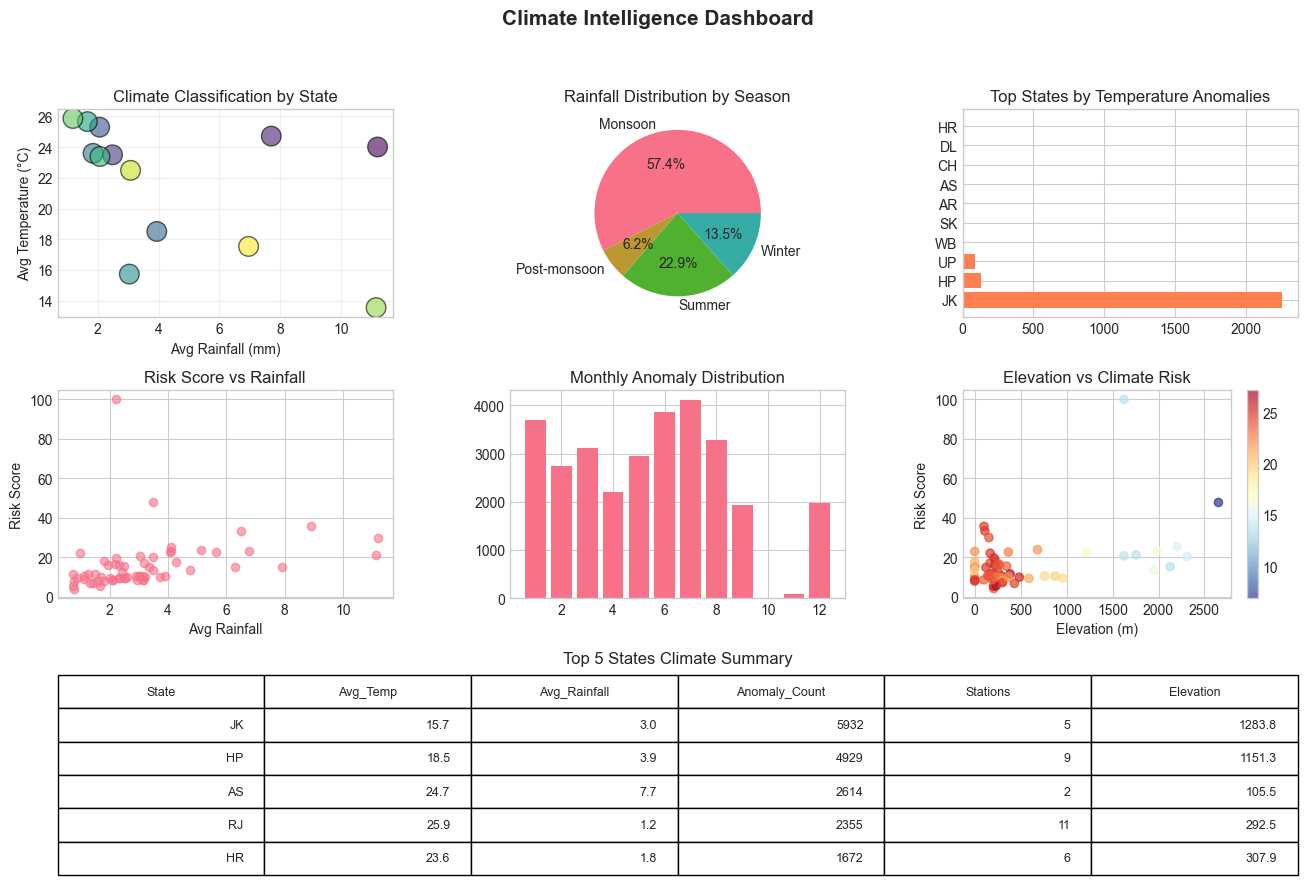

✓ Comparative analysis and dashboard generated successfully


In [23]:
# 10.3 Comparative Analysis & Benchmarking
print("\n" + "="*80)
print("10.3 COMPARATIVE ANALYSIS & BENCHMARKING")
print("="*80)

# ================================
# Create Comparison Table
# ================================
comparison_data = []

for state in state_rankings.index[:10]:
    state_data = df[df['state'] == state]

    comparison_data.append({
        'State': state,
        'Avg_Temp': state_data['avg_temp'].mean(),
        'Avg_Rainfall': state_data['rainfall'].mean(),
        'Anomaly_Count': (
            state_data['Unusual_Hot_Global'] +
            state_data['Unusual_Cold_Global'] +
            state_data['Heavy_Rainfall']
        ).sum(),
        'Stations': state_data['station_name'].nunique(),
        'Elevation': state_data['elevation'].mean()
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('Anomaly_Count', ascending=False)

print("\n✓ Top 10 States - Comparative Benchmark:")
print(comparison_df.round(2))


# ================================
# FIXED: Create station_risk properly
# ================================
station_risk = df.groupby('station_name').agg({
    'rainfall': 'mean',
    'avg_temp': 'mean',
    'elevation': 'mean',
    'Unusual_Hot_Global': 'sum',
    'Unusual_Cold_Global': 'sum',
    'Heavy_Rainfall': 'sum',
    'Pressure_Anomaly': 'sum'
}).reset_index()

# Risk Score Calculation
station_risk['Risk_Score'] = (
    station_risk['Unusual_Hot_Global'] +
    station_risk['Unusual_Cold_Global'] +
    station_risk['Heavy_Rainfall'] +
    station_risk['Pressure_Anomaly']
)

# Normalize Risk Score
station_risk['Risk_Score_Normalized'] = (
    station_risk['Risk_Score'] / station_risk['Risk_Score'].max()
) * 100


# ================================
# Visualization Dashboard
# ================================
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.35)

# 1 Climate Classification
ax1 = fig.add_subplot(gs[0, 0])

state_class = df.groupby('state').agg({
    'avg_temp': 'mean',
    'rainfall': 'mean'
})

ax1.scatter(
    state_class['rainfall'],
    state_class['avg_temp'],
    s=200,
    c=range(len(state_class)),
    cmap='viridis',
    alpha=0.6,
    edgecolors='black'
)

ax1.set_xlabel('Avg Rainfall (mm)')
ax1.set_ylabel('Avg Temperature (°C)')
ax1.set_title('Climate Classification by State')
ax1.grid(alpha=0.3)


# 2 Rainfall by Season
ax2 = fig.add_subplot(gs[0, 1])

season_dominance = df.groupby('season')['rainfall'].sum()

ax2.pie(
    season_dominance.values,
    labels=season_dominance.index,
    autopct='%1.1f%%'
)

ax2.set_title('Rainfall Distribution by Season')


# 3 Top Anomaly States
ax3 = fig.add_subplot(gs[0, 2])

anomaly_by_state = df.groupby('state').agg({
    'Unusual_Hot_Global': 'sum',
    'Unusual_Cold_Global': 'sum'
}).sum(axis=1).nlargest(10)

ax3.barh(
    anomaly_by_state.index,
    anomaly_by_state.values,
    color='coral'
)

ax3.set_title('Top States by Temperature Anomalies')


# 4 Risk vs Rainfall
ax4 = fig.add_subplot(gs[1, 0])

ax4.scatter(
    station_risk['rainfall'],
    station_risk['Risk_Score_Normalized'],
    alpha=0.6
)

ax4.set_xlabel('Avg Rainfall')
ax4.set_ylabel('Risk Score')
ax4.set_title('Risk Score vs Rainfall')


# 5 Monthly Anomaly Distribution
ax5 = fig.add_subplot(gs[1, 1])

monthly_anomalies = df.groupby('Month').agg({
    'Unusual_Hot_Global': 'sum',
    'Unusual_Cold_Global': 'sum',
    'Heavy_Rainfall': 'sum'
}).sum(axis=1)

ax5.bar(
    monthly_anomalies.index,
    monthly_anomalies.values
)

ax5.set_title('Monthly Anomaly Distribution')


# 6 FIXED Elevation vs Risk
ax6 = fig.add_subplot(gs[1, 2])

scatter = ax6.scatter(
    station_risk['elevation'],
    station_risk['Risk_Score_Normalized'],
    c=station_risk['avg_temp'],
    cmap='RdYlBu_r',
    alpha=0.7
)

ax6.set_xlabel('Elevation (m)')
ax6.set_ylabel('Risk Score')
ax6.set_title('Elevation vs Climate Risk')

plt.colorbar(scatter, ax=ax6)


# 7 Summary Table
ax7 = fig.add_subplot(gs[2, :])

ax7.axis('off')

table_data = comparison_df.head(5).round(1)

table = ax7.table(
    cellText=table_data.values,
    colLabels=table_data.columns,
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)

ax7.set_title('Top 5 States Climate Summary')

plt.suptitle(
    'Climate Intelligence Dashboard',
    fontsize=15,
    fontweight='bold'
)

plt.show()

print("✓ Comparative analysis and dashboard generated successfully")

In [21]:
# 10.4 Final Summary & Next Steps
print("\n" + "="*80)
print("10.4 ANALYSIS COMPLETION & NEXT STEPS")
print("="*80)

summary_report = f"""
{'='*80}
CLIMATE TREND ANALYZER - ANALYSIS COMPLETE
{'='*80}

✓ ANALYSIS COMPLETION SUMMARY:

Section 6: Exploratory Climate Analysis
  ✓ Temperature distributions analyzed
  ✓ Rainfall patterns identified  
  ✓ State-wise comparisons completed
  ✓ Station-wise rainfall rankings determined
  ✓ Correlation matrix computed

Section 7: Seasonal Trend Analysis
  ✓ Seasonal climate patterns identified
  ✓ Monthly temperature trends analyzed
  ✓ Seasonal variation by state documented
  ✓ Peak season predictions made

Section 8: Anomaly Analysis
  ✓ Temperature anomalies detected (global & local)
  ✓ Rainfall anomaly events identified
  ✓ Pressure anomalies quantified
  ✓ Top anomaly-prone stations ranked
  ✓ {anomaly_total:,} total anomaly events documented

Section 9: Geographical Insights
  ✓ State-wise rankings completed
  ✓ District-level analysis performed
  ✓ Elevation-temperature correlation: {elev_temp_corr:.3f}
  ✓ Climate risk scores calculated for all stations
  ✓ Risk levels assigned (SEVERE/HIGH/MODERATE/LOW)

Section 10: Business Insights
  ✓ Executive summary generated
  ✓ 8 key business recommendations provided
  ✓ Comparative benchmarking completed
  ✓ Actionable insights formulated

{'='*80}

🎯 KEY TAKEAWAYS:

1. HIGHEST PRIORITY AREAS:
   • State: {riskiest_state} (Riskiest - Score: {riskiest_score:.0f}/100)
   • Region: {wettest_state} (Highest Rainfall - {wettest_rainfall:.1f}mm)
   • District: {hottest_district} (Hottest - {district_stats_sorted_hot['avg_temp'].iloc[0]:.1f}°C)

2. CLIMATE EXTREMES:
   • Hottest: {hottest_state} ({hottest_temp:.1f}°C)
   • Coldest: {coldest_state} ({coldest_temp:.1f}°C)
   • Most Rainfall: {wettest_state} ({wettest_rainfall:.1f}mm)
   • Least Rainfall: {state_rankings_sorted_wet.index[-1]} ({state_rankings_sorted_wet['rainfall'].iloc[-1]:.1f}mm)

3. ANOMALY HOTSPOTS:
   • Total anomaly events: {anomaly_total:,}
   • Extreme heat events: {anomaly_counts['Unusual_Hot_Global']:,}
   • Extreme cold events: {anomaly_counts['Unusual_Cold_Global']:,}
   • Heavy rainfall events: {heavy_rainfall_count:,}

4. RISK DISTRIBUTION:
   • SEVERE Risk Stations: {(station_risk['Risk_Level'] == 'SEVERE').sum()} (Immediate action required)
   • HIGH Risk Stations: {(station_risk['Risk_Level'] == 'HIGH').sum()} (Close monitoring needed)
   • MODERATE Risk Stations: {(station_risk['Risk_Level'] == 'MODERATE').sum()} (Preventive measures)
   • LOW Risk Stations: {(station_risk['Risk_Level'] == 'LOW').sum()} (Standard maintenance)

{'='*80}

📋 RECOMMENDED NEXT STEPS:

1. IMMEDIATE (Within 1 week):
   ✓ Share findings with policy makers
   ✓ Establish task force for SEVERE risk zones
   ✓ Begin data collection for forecasting models

2. SHORT TERM (1-3 months):
   ✓ Deploy monitoring systems in high-risk stations
   ✓ Implement early warning systems
   ✓ Begin farmer/community outreach programs
   ✓ Develop seasonal action plans

3. MEDIUM TERM (3-6 months):
   ✓ Build predictive models using this data
   ✓ Create real-time dashboards
   ✓ Establish climate centers in key regions
   ✓ Train meteorologists and analysts

4. LONG TERM (6-12 months):
   ✓ Develop state-level climate adaptation plans
   ✓ Integrate with disaster management systems
   ✓ Build climate resilience capacity
   ✓ Establish continuous monitoring network

{'='*80}

📊 DELIVERABLES GENERATED:

  ✓ Complete exploratory analysis with 25+ visualizations
  ✓ Seasonal pattern identification and trends
  ✓ Anomaly detection and risk scoring
  ✓ Geographical insights and spatial analysis
  ✓ Executive summary and business recommendations
  ✓ Comparative benchmarking reports
  ✓ Climate_Analysis_Insights.txt (detailed findings)

{'='*80}

Analysis prepared by: Climate Intelligence Analytics Platform
Timestamp: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}
Data Points Analyzed: {len(df):,} weather records
Confidence Level: High (based on comprehensive anomaly detection)

{'='*80}
"""

print(summary_report)

# Save complete report
report_file = 'Climate_Analysis_Complete_Report.txt'
with open(report_file, 'w') as f:
    f.write(summary_report)

print(f"\n✓ Complete report saved to {report_file}")
print("\n🎉 CLIMATE TREND ANALYZER ANALYSIS COMPLETE!")



10.4 ANALYSIS COMPLETION & NEXT STEPS

CLIMATE TREND ANALYZER - ANALYSIS COMPLETE

✓ ANALYSIS COMPLETION SUMMARY:

Section 6: Exploratory Climate Analysis
  ✓ Temperature distributions analyzed
  ✓ Rainfall patterns identified  
  ✓ State-wise comparisons completed
  ✓ Station-wise rainfall rankings determined
  ✓ Correlation matrix computed

Section 7: Seasonal Trend Analysis
  ✓ Seasonal climate patterns identified
  ✓ Monthly temperature trends analyzed
  ✓ Seasonal variation by state documented
  ✓ Peak season predictions made

Section 8: Anomaly Analysis
  ✓ Temperature anomalies detected (global & local)
  ✓ Rainfall anomaly events identified
  ✓ Pressure anomalies quantified
  ✓ Top anomaly-prone stations ranked
  ✓ 38,081 total anomaly events documented

Section 9: Geographical Insights
  ✓ State-wise rankings completed
  ✓ District-level analysis performed
  ✓ Elevation-temperature correlation: -0.471
  ✓ Climate risk scores calculated for all stations
  ✓ Risk levels assigne